# Baseline 001 — Cost, Performance, Accuracy, and Tool-Usage Analysis

This notebook analyzes the `baseline_001` experiment from `experiments/baseline_001/`.
It covers cost, performance, accuracy, judge behavior, and tool usage.

A specific adjustment is included for **Gemini native MCP input-token accounting**. In Gemini native MCP runs, direct prompt tokens and native tool-use prompt tokens are reported separately. Therefore, this notebook derives an adjusted input-token metric:

```text
adjusted_query_input_tokens = prompt_token_count + tool_use_prompt_token_count
```

Provider-reported **total query tokens** remain the main total-cost metric. Adjusted input tokens are used for all input/context-size analyses and for Figure 1.


In [1]:
from pathlib import Path
from collections import Counter
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.width", 180)

CANDIDATE_DIRS = [
    Path("experiments") / "baseline_001",
    Path("baseline_001"),
]
BASE_DIR = next((p for p in CANDIDATE_DIRS if p.exists()), None)
if BASE_DIR is None:
    raise FileNotFoundError(
        "Could not find baseline_001 artifacts. Set BASE_DIR to the directory containing answers.jsonl, evals.jsonl, judge_votes.jsonl, and queries.jsonl."
    )

print(f"Experiment directory: {BASE_DIR.resolve()}")


Experiment directory: /home/michel/repos/doutorado/contextbench-lattes/experiments/baseline_001


## 1. Load artifacts and normalize metrics

The notebook reads `answers.jsonl`, `evals.jsonl`, `judge_votes.jsonl`, and `queries.jsonl`. Cost metrics use only the query phase. Evaluation/judge tokens are excluded from answer-generation cost.


In [2]:
def read_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    if not path.exists():
        return pd.DataFrame()
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.json_normalize(rows) if rows else pd.DataFrame()

answers = read_jsonl(BASE_DIR / "answers.jsonl")
evals = read_jsonl(BASE_DIR / "evals.jsonl")
judge_votes = read_jsonl(BASE_DIR / "judge_votes.jsonl")
queries = read_jsonl(BASE_DIR / "queries.jsonl")

display(pd.DataFrame([
    {"Artifact": "answers.jsonl", "Rows": len(answers)},
    {"Artifact": "evals.jsonl", "Rows": len(evals)},
    {"Artifact": "judge_votes.jsonl", "Rows": len(judge_votes)},
    {"Artifact": "queries.jsonl", "Rows": len(queries)},
]))

if answers.empty or judge_votes.empty:
    raise ValueError("answers.jsonl and judge_votes.jsonl are required for this notebook.")


def effective_strategy(row: pd.Series) -> str:
    if row.get("strategy") == "inline":
        return f"inline_{row.get('format')}"
    return row.get("strategy")


def normalize_tags(value):
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    if isinstance(value, str):
        try:
            parsed = json.loads(value)
            return parsed if isinstance(parsed, list) else [value]
        except Exception:
            return [value]
    return []

answers = answers.copy()
answers["effective_strategy"] = answers.apply(effective_strategy, axis=1)
answers["query_total_tokens"] = pd.to_numeric(answers.get("metricsSummary.totalTokens", answers.get("usage.totalTokens")), errors="coerce")
answers["query_input_tokens_reported"] = pd.to_numeric(answers.get("metricsSummary.inputTokens", answers.get("usage.inputTokens")), errors="coerce")
answers["query_output_tokens"] = pd.to_numeric(answers.get("metricsSummary.outputTokens", answers.get("usage.outputTokens")), errors="coerce")
answers["query_duration_ms"] = pd.to_numeric(answers.get("metricsSummary.totalDurationMs", answers.get("timing.durationMs")), errors="coerce")
answers["query_duration_s"] = answers["query_duration_ms"] / 1000.0
answers["model_calls"] = pd.to_numeric(answers.get("metricsSummary.modelCalls"), errors="coerce")

# Backward-compatible aliases for ad hoc analysis.
answers["query_tokens"] = answers["query_total_tokens"]
answers["query_input_tokens"] = answers["query_input_tokens_reported"]

for col in ["metricsSummary.toolCalls", "metricsSummary.functionCalls", "metricsSummary.mcpToolCalls"]:
    if col not in answers.columns:
        answers[col] = 0
    answers[col] = pd.to_numeric(answers[col], errors="coerce").fillna(0)

answers["aggregate_tool_calls"] = answers[[
    "metricsSummary.toolCalls", "metricsSummary.functionCalls", "metricsSummary.mcpToolCalls"
]].max(axis=1)

judge_votes = judge_votes.copy()
judge_votes["correctness_rating"] = judge_votes.get("criterias.correctness.rating")
judge_votes["completeness_rating"] = judge_votes.get("criterias.completeness.rating")
judge_votes["correctness_meets"] = judge_votes["correctness_rating"].eq("meets")
judge_votes["completeness_meets"] = judge_votes["completeness_rating"].eq("meets")
judge_votes["both_criteria_meet"] = judge_votes["correctness_meets"] & judge_votes["completeness_meets"]

run_votes = (
    judge_votes
    .groupby("runId")
    .agg(
        judge_count=("judgeId", "nunique"),
        both_criteria_meet_votes=("both_criteria_meet", "sum"),
        correctness_meets_votes=("correctness_meets", "sum"),
        completeness_meets_votes=("completeness_meets", "sum"),
    )
    .reset_index()
)
run_votes["majority_correct"] = run_votes["both_criteria_meet_votes"] >= 2
run_votes["unanimous_correct"] = run_votes["both_criteria_meet_votes"] == run_votes["judge_count"]
run_votes["majority_correctness"] = run_votes["correctness_meets_votes"] >= 2
run_votes["majority_completeness"] = run_votes["completeness_meets_votes"] >= 2

runs = answers.merge(run_votes, on="runId", how="left")
for col in ["majority_correct", "unanimous_correct", "majority_correctness", "majority_completeness"]:
    runs[col] = runs[col].fillna(False).astype(bool)
runs["questionTagsList"] = runs.get("questionTags", pd.Series([None] * len(runs))).apply(normalize_tags)

print(f"Runs: {len(runs):,}")
print(f"Strategies: {', '.join(sorted(runs['effective_strategy'].dropna().unique()))}")
print(f"Models: {', '.join(sorted(runs['model'].dropna().unique()))}")
print(f"Questions: {runs['questionId'].nunique()}")
print(f"Instances: {runs['instanceId'].nunique()}")
print(f"Query total tokens: {runs['query_total_tokens'].sum():,.0f}")
print(f"Evaluation tokens excluded from query-cost metrics: {pd.to_numeric(judge_votes.get('totalTokens'), errors='coerce').sum():,.0f}")


,Artifact,Rows
0,answers.jsonl,1200
1,evals.jsonl,1200
2,judge_votes.jsonl,3600
3,queries.jsonl,1200


Runs: 1,200
Strategies: inline_html, inline_json, local_function, local_mcp, mcp
Models: gemini-2.5-flash, gemini-2.5-flash-lite, gpt-5.4-mini, gpt-5.4-nano
Questions: 12
Instances: 5
Query total tokens: 43,949,364
Evaluation tokens excluded from query-cost metrics: 28,499,668


## 2. Gemini native MCP token audit

Gemini native MCP exposes direct prompt tokens as `prompt_token_count` and MCP/tool-use prompt tokens as `tool_use_prompt_token_count`. The field `metricsSummary.inputTokens` only captures the direct prompt part for these runs, so this notebook adds the native tool-use prompt tokens when computing adjusted input tokens.


In [3]:
def read_query_trace(run_id: str, trace_ref: str | None = None) -> dict:
    candidates = []
    if isinstance(trace_ref, str) and trace_ref:
        p = Path(trace_ref)
        candidates.append(p if p.is_absolute() else BASE_DIR / p)
    candidates.append(BASE_DIR / "traces" / "queries" / f"{run_id}.json")
    for path in candidates:
        if path.exists():
            try:
                return json.loads(path.read_text(encoding="utf-8"))
            except Exception:
                return {}
    return {}


def raw_usage_metadata(trace_obj: dict) -> dict:
    trace = trace_obj.get("trace", trace_obj) if isinstance(trace_obj, dict) else {}
    raw = trace.get("rawResponse", {}) if isinstance(trace, dict) else {}
    if not isinstance(raw, dict):
        return {}
    return raw.get("usage_metadata") or raw.get("usageMetadata") or {}


def native_mcp_metadata(trace_obj: dict) -> dict:
    trace = trace_obj.get("trace", trace_obj) if isinstance(trace_obj, dict) else {}
    native = trace.get("nativeMcp", {}) if isinstance(trace, dict) else {}
    return native if isinstance(native, dict) else {}

runs["gemini_prompt_token_count"] = np.nan
runs["gemini_tool_use_prompt_token_count"] = np.nan
runs["gemini_candidates_token_count"] = np.nan
runs["gemini_thoughts_token_count"] = np.nan
runs["gemini_total_token_count"] = np.nan
runs["native_mcp_visible_tool_call_count"] = 0

is_gemini = (
    runs["model"].astype(str).str.contains("gemini", case=False, na=False)
    | runs.get("provider", pd.Series([""] * len(runs))).astype(str).str.contains("google", case=False, na=False)
)
is_remote_mcp = runs["strategy"].astype(str).eq("mcp")
gemini_mcp_mask = is_gemini & is_remote_mcp

for idx, row in runs.loc[gemini_mcp_mask].iterrows():
    trace_obj = read_query_trace(row["runId"], row.get("traceRef"))
    usage = raw_usage_metadata(trace_obj)
    native = native_mcp_metadata(trace_obj)
    runs.at[idx, "gemini_prompt_token_count"] = usage.get("prompt_token_count", np.nan)
    runs.at[idx, "gemini_tool_use_prompt_token_count"] = usage.get("tool_use_prompt_token_count", np.nan)
    runs.at[idx, "gemini_candidates_token_count"] = usage.get("candidates_token_count", np.nan)
    runs.at[idx, "gemini_thoughts_token_count"] = usage.get("thoughts_token_count", np.nan)
    runs.at[idx, "gemini_total_token_count"] = usage.get("total_token_count", np.nan)
    runs.at[idx, "native_mcp_visible_tool_call_count"] = native.get("visibleToolCallCount", 0) or 0

runs["query_tool_use_prompt_tokens"] = runs["gemini_tool_use_prompt_token_count"].fillna(0)
runs["query_input_tokens_adjusted"] = runs["query_input_tokens_reported"].copy()

adjusted_gemini_input = (
    runs.loc[gemini_mcp_mask, "gemini_prompt_token_count"].fillna(runs.loc[gemini_mcp_mask, "query_input_tokens_reported"])
    + runs.loc[gemini_mcp_mask, "gemini_tool_use_prompt_token_count"].fillna(0)
)
runs.loc[gemini_mcp_mask, "query_input_tokens_adjusted"] = adjusted_gemini_input
runs["query_adjusted_input_tokens"] = runs["query_input_tokens_adjusted"]

gemini_mcp_token_audit = runs.loc[gemini_mcp_mask, [
    "runId", "model", "questionId", "native_mcp_visible_tool_call_count",
    "query_input_tokens_reported", "gemini_prompt_token_count", "gemini_tool_use_prompt_token_count",
    "query_input_tokens_adjusted", "gemini_candidates_token_count", "gemini_thoughts_token_count",
    "query_total_tokens", "gemini_total_token_count",
]].copy()

audit_summary = (
    gemini_mcp_token_audit
    .groupby(["model", "native_mcp_visible_tool_call_count"], as_index=False)
    .agg(
        Runs=("runId", "count"),
        Mean_Reported_Input_Tokens=("query_input_tokens_reported", "mean"),
        Mean_Tool_Use_Prompt_Tokens=("gemini_tool_use_prompt_token_count", "mean"),
        Mean_Adjusted_Input_Tokens=("query_input_tokens_adjusted", "mean"),
        Mean_Output_Tokens=("gemini_candidates_token_count", "mean"),
        Mean_Thinking_Tokens=("gemini_thoughts_token_count", "mean"),
        Mean_Total_Tokens=("query_total_tokens", "mean"),
    )
    .round(1)
)

display(audit_summary)
display(Markdown(
    "**Interpretation.** For Gemini remote MCP, reported input tokens are often only the direct prompt. "
    "The adjusted input-token metric adds native tool-use prompt tokens from the raw Gemini response. "
    "Total query tokens remain the main cost metric, while adjusted input tokens should be used for input/context-size analysis."
))


,model,native_mcp_visible_tool_call_count,Runs,Mean_Reported_Input_Tokens,Mean_Tool_Use_Prompt_Tokens,Mean_Adjusted_Input_Tokens,Mean_Output_Tokens,Mean_Thinking_Tokens,Mean_Total_Tokens
0,gemini-2.5-flash,0,21,144.7,NaN,144.7,40.4,314.3,499.4
1,gemini-2.5-flash,1,34,150.8,375.1,525.9,121.1,451.1,1098.1
2,gemini-2.5-flash,3,3,158.0,562.3,720.3,945.3,2357.3,4023.0
3,gemini-2.5-flash,4,2,160.0,874.0,1034.0,789.5,1600.0,3423.5
4,gemini-2.5-flash-lite,0,29,147.9,NaN,147.9,40.4,NaN,188.3
5,gemini-2.5-flash-lite,1,24,152.1,152.1,304.2,96.2,NaN,400.5
6,gemini-2.5-flash-lite,2,4,143.5,165.5,309.0,174.2,NaN,483.2
7,gemini-2.5-flash-lite,5,3,148.0,148.0,296.0,275.3,NaN,571.3


**Interpretation.** For Gemini remote MCP, reported input tokens are often only the direct prompt. The adjusted input-token metric adds native tool-use prompt tokens from the raw Gemini response. Total query tokens remain the main cost metric, while adjusted input tokens should be used for input/context-size analysis.

## 3. Table 1 — Cost per Correct Answer by Strategy and Model

This table reports total query tokens and adjusted input tokens per successful answer. `Total Tokens per Majority Correct` is the primary provider-cost efficiency metric. `Input Tokens per Majority Correct` is the context/input efficiency metric.


In [4]:
def safe_div(num, den):
    return num / den.replace(0, np.nan) if isinstance(den, pd.Series) else num / (np.nan if den == 0 else den)

cost_table = (
    runs
    .groupby(["effective_strategy", "model"], dropna=False)
    .agg(
        Runs=("runId", "count"),
        Query_Total_Tokens=("query_total_tokens", "sum"),
        Adjusted_Input_Tokens=("query_input_tokens_adjusted", "sum"),
        Mean_Query_Total_Tokens=("query_total_tokens", "mean"),
        Mean_Adjusted_Input_Tokens=("query_input_tokens_adjusted", "mean"),
        Mean_Query_Time_s=("query_duration_s", "mean"),
        Majority_Correct=("majority_correct", "sum"),
        Unanimous_Correct=("unanimous_correct", "sum"),
    )
    .reset_index()
)
cost_table["Majority_Accuracy"] = cost_table["Majority_Correct"] / cost_table["Runs"]
cost_table["Unanimous_Accuracy"] = cost_table["Unanimous_Correct"] / cost_table["Runs"]
cost_table["Total_Tokens_per_Majority_Correct"] = safe_div(cost_table["Query_Total_Tokens"], cost_table["Majority_Correct"])
cost_table["Input_Tokens_per_Majority_Correct"] = safe_div(cost_table["Adjusted_Input_Tokens"], cost_table["Majority_Correct"])
cost_table["Total_Tokens_per_Unanimous_Correct"] = safe_div(cost_table["Query_Total_Tokens"], cost_table["Unanimous_Correct"])

cost_table_display = cost_table[[
    "effective_strategy", "model", "Runs", "Query_Total_Tokens", "Adjusted_Input_Tokens",
    "Majority_Correct", "Majority_Accuracy", "Unanimous_Correct", "Unanimous_Accuracy",
    "Total_Tokens_per_Majority_Correct", "Input_Tokens_per_Majority_Correct",
    "Total_Tokens_per_Unanimous_Correct", "Mean_Query_Time_s",
]].rename(columns={
    "effective_strategy": "Strategy",
    "model": "Model",
    "Query_Total_Tokens": "Query Total Tokens",
    "Adjusted_Input_Tokens": "Adjusted Input Tokens",
    "Majority_Correct": "Majority Correct",
    "Majority_Accuracy": "Majority Accuracy",
    "Unanimous_Correct": "Unanimous Correct",
    "Unanimous_Accuracy": "Unanimous Accuracy",
    "Total_Tokens_per_Majority_Correct": "Total Tokens per Majority Correct",
    "Input_Tokens_per_Majority_Correct": "Input Tokens per Majority Correct",
    "Total_Tokens_per_Unanimous_Correct": "Total Tokens per Unanimous Correct",
    "Mean_Query_Time_s": "Mean Query Time (s)",
}).sort_values(["Total Tokens per Majority Correct", "Strategy", "Model"])

display(cost_table_display.style.format({
    "Query Total Tokens": "{:,.0f}".format,
    "Adjusted Input Tokens": "{:,.0f}".format,
    "Majority Accuracy": "{:.1%}".format,
    "Unanimous Accuracy": "{:.1%}".format,
    "Total Tokens per Majority Correct": lambda x: "—" if pd.isna(x) else f"{x:,.0f}",
    "Input Tokens per Majority Correct": lambda x: "—" if pd.isna(x) else f"{x:,.0f}",
    "Total Tokens per Unanimous Correct": lambda x: "—" if pd.isna(x) else f"{x:,.0f}",
    "Mean Query Time (s)": "{:.2f}".format,
}))

best_total = cost_table_display.dropna(subset=["Total Tokens per Majority Correct"]).iloc[0]
best_input = cost_table_display.dropna(subset=["Input Tokens per Majority Correct"]).sort_values("Input Tokens per Majority Correct").iloc[0]
text = (
    f"**Table 1 interpretation.** The best configuration by provider-reported total tokens per majority-correct answer is "
    f"**{best_total['Strategy']} / {best_total['Model']}** ({best_total['Total Tokens per Majority Correct']:,.0f} total tokens per majority-correct answer). "
    f"By adjusted input tokens, the best configuration is **{best_input['Strategy']} / {best_input['Model']}** "
    f"({best_input['Input Tokens per Majority Correct']:,.0f} adjusted input tokens per majority-correct answer)."
)
display(Markdown(text))


,Strategy,Model,Runs,Query Total Tokens,Adjusted Input Tokens,Majority Correct,Majority Accuracy,Unanimous Correct,Unanimous Accuracy,Total Tokens per Majority Correct,Input Tokens per Majority Correct,Total Tokens per Unanimous Correct,Mean Query Time (s)
17,mcp,gemini-2.5-flash-lite,60,"18,720","13,716",9,15.0%,2,3.3%,"2,080","1,524","9,360",4.27
16,mcp,gemini-2.5-flash,60,"66,739","25,146",17,28.3%,4,6.7%,"3,926","1,479","16,685",6.28
13,local_mcp,gemini-2.5-flash-lite,60,"279,566","271,344",13,21.7%,3,5.0%,"21,505","20,873","93,189",3.55
8,local_function,gemini-2.5-flash,60,"368,455","325,939",16,26.7%,7,11.7%,"23,028","20,371","52,636",5.20
12,local_mcp,gemini-2.5-flash,60,"385,611","350,497",14,23.3%,4,6.7%,"27,544","25,036","96,403",4.65
9,local_function,gemini-2.5-flash-lite,60,"266,756","260,862",9,15.0%,3,5.0%,"29,640","28,985","88,919",3.45
11,local_function,gpt-5.4-nano,60,"966,912","939,504",32,53.3%,20,33.3%,"30,216","29,360","48,346",6.71
18,mcp,gpt-5.4-mini,60,"1,029,828","981,668",31,51.7%,12,20.0%,"33,220","31,667","85,819",9.30
19,mcp,gpt-5.4-nano,60,"1,045,570","1,017,810",29,48.3%,17,28.3%,"36,054","35,097","61,504",8.41
14,local_mcp,gpt-5.4-mini,60,"1,231,107","1,188,365",32,53.3%,18,30.0%,"38,472","37,136","68,395",6.74


**Table 1 interpretation.** The best configuration by provider-reported total tokens per majority-correct answer is **mcp / gemini-2.5-flash-lite** (2,080 total tokens per majority-correct answer). By adjusted input tokens, the best configuration is **mcp / gemini-2.5-flash** (1,479 adjusted input tokens per majority-correct answer).

## 4. Table 2 — Question-Level Accuracy by Agreement Type

This table identifies easy and hard questions and shows both total query tokens and adjusted input tokens.


In [5]:
def failure_label(row):
    if bool(row.get("majority_correct")):
        return "Majority correct"
    if not bool(row.get("majority_correctness")) and not bool(row.get("majority_completeness")):
        return "Both correctness and completeness"
    if not bool(row.get("majority_correctness")):
        return "Correctness only"
    if not bool(row.get("majority_completeness")):
        return "Completeness only"
    return "Mixed judge-level disagreement"

runs["failure_label"] = runs.apply(failure_label, axis=1)
question_tags = (
    runs[["questionId", "questionTagsList"]]
    .drop_duplicates(subset=["questionId"])
    .assign(Tags=lambda df: df["questionTagsList"].apply(lambda xs: ", ".join(xs)))
    [["questionId", "Tags"]]
)
failure_mode = (
    runs[runs["majority_correct"] == False]
    .groupby("questionId")["failure_label"]
    .agg(lambda s: s.value_counts().idxmax() if len(s) else "No majority failures")
    .reset_index(name="Most Common Failure")
)
question_table = (
    runs
    .groupby("questionId")
    .agg(
        Runs=("runId", "count"),
        Majority_Correct=("majority_correct", "sum"),
        Unanimous_Correct=("unanimous_correct", "sum"),
        Mean_Query_Total_Tokens=("query_total_tokens", "mean"),
        Mean_Adjusted_Input_Tokens=("query_input_tokens_adjusted", "mean"),
        Mean_Query_Time_s=("query_duration_s", "mean"),
    )
    .reset_index()
    .merge(question_tags, on="questionId", how="left")
    .merge(failure_mode, on="questionId", how="left")
)
question_table["Majority_Accuracy"] = question_table["Majority_Correct"] / question_table["Runs"]
question_table["Unanimous_Accuracy"] = question_table["Unanimous_Correct"] / question_table["Runs"]
question_table_display = question_table[[
    "questionId", "Tags", "Runs", "Majority_Correct", "Majority_Accuracy",
    "Unanimous_Correct", "Unanimous_Accuracy", "Mean_Query_Total_Tokens",
    "Mean_Adjusted_Input_Tokens", "Mean_Query_Time_s", "Most Common Failure",
]].rename(columns={
    "questionId": "Question",
    "Majority_Correct": "Majority Correct",
    "Majority_Accuracy": "Majority Accuracy",
    "Unanimous_Correct": "Unanimous Correct",
    "Unanimous_Accuracy": "Unanimous Accuracy",
    "Mean_Query_Total_Tokens": "Mean Query Total Tokens",
    "Mean_Adjusted_Input_Tokens": "Mean Adjusted Input Tokens",
    "Mean_Query_Time_s": "Mean Query Time (s)",
}).sort_values("Majority Accuracy", ascending=False)

display(question_table_display.style.format({
    "Majority Accuracy": "{:.1%}".format,
    "Unanimous Accuracy": "{:.1%}".format,
    "Mean Query Total Tokens": "{:,.0f}".format,
    "Mean Adjusted Input Tokens": "{:,.0f}".format,
    "Mean Query Time (s)": "{:.2f}".format,
}))

q_best = question_table_display.iloc[0]
q_worst = question_table_display.sort_values("Majority Accuracy").iloc[0]
display(Markdown(
    f"**Table 2 interpretation.** The easiest question by majority accuracy is **{q_best['Question']}** ({q_best['Majority Accuracy']:.1%}), "
    f"while the hardest is **{q_worst['Question']}** ({q_worst['Majority Accuracy']:.1%}). "
    "The token columns show that higher input or total token usage does not necessarily imply higher accuracy."
))


,Question,Tags,Runs,Majority Correct,Majority Accuracy,Unanimous Correct,Unanimous Accuracy,Mean Query Total Tokens,Mean Adjusted Input Tokens,Mean Query Time (s),Most Common Failure
4,q_field,"inferential, ranking",100,87,87.0%,58,58.0%,"31,408","31,275",4.59,Completeness only
7,q_projfit_2,"inferential, cross-block",100,62,62.0%,32,32.0%,"40,716","39,785",8.74,Both correctness and completeness
5,q_indexed,"weak-data, quantitative",100,58,58.0%,23,23.0%,"42,894","42,520",5.76,Both correctness and completeness
3,q_en,factual,100,52,52.0%,52,52.0%,"32,960","32,848",4.11,Both correctness and completeness
11,q_techprod,"weak-data, quantitative",100,48,48.0%,29,29.0%,"32,927","32,634",5.24,Both correctness and completeness
6,q_phd,"factual, temporal",100,45,45.0%,23,23.0%,"30,864","30,676",5.62,Correctness only
0,q_admin,factual,100,38,38.0%,19,19.0%,"37,463","36,862",6.93,Both correctness and completeness
8,q_pubyear,"weak-data, temporal, ranking",100,34,34.0%,5,5.0%,"31,567","31,077",5.59,Both correctness and completeness
1,q_advpub,"inferential, cross-block, quantitative, matching",100,30,30.0%,2,2.0%,"45,321","44,648",7.03,Both correctness and completeness
2,q_coauth,"inferential, quantitative, ranking, matching",100,7,7.0%,0,0.0%,"44,150","42,976",9.13,Both correctness and completeness


**Table 2 interpretation.** The easiest question by majority accuracy is **q_field** (87.0%), while the hardest is **q_sup** (0.0%). The token columns show that higher input or total token usage does not necessarily imply higher accuracy.

## 5. Table 3 — Observed Tool Usage by Question and Strategy

This section uses the trace-derived CSVs generated by `extract_observed_calls.py` as the official source for observed operation calls. This is important for remote MCP (`mcp`), because provider-native MCP calls are not consistently reflected in `metricsSummary.toolCalls` or `trace.toolCalls`.

In [6]:
TOOL_BASED_STRATEGIES = ["local_function", "local_mcp", "mcp"]

OBSERVED_CALLS_BY_RUN_PATH = BASE_DIR / "observed_tool_calls_by_run.csv"
OBSERVED_CALLS_LONG_PATH = BASE_DIR / "observed_tool_calls_long.csv"
OBSERVED_CALLS_SUMMARY_PATH = BASE_DIR / "observed_tool_calls_summary.csv"

runs = runs.copy()
runs["legacy_aggregate_tool_calls"] = runs.get("aggregate_tool_calls", 0)

observed_calls_by_run = pd.DataFrame()
observed_calls_long = pd.DataFrame()
observed_calls_summary = pd.DataFrame()

if OBSERVED_CALLS_BY_RUN_PATH.exists():
    observed_calls_by_run = pd.read_csv(OBSERVED_CALLS_BY_RUN_PATH)
    numeric_cols = [
        "metricsToolCalls", "metricsMcpToolCalls", "metricsFunctionCalls", "metricsModelCalls", "metricsSteps",
        "observedCallCount", "observedCallCoverage", "nativeMcpCallCount", "nativeMcpVisibleToolCallCount",
        "nativeMcpApprovalRequestCount", "rawResponseHasMcpEvidence",
    ]
    for col in numeric_cols:
        if col in observed_calls_by_run.columns:
            observed_calls_by_run[col] = pd.to_numeric(observed_calls_by_run[col], errors="coerce")

    merge_cols = [
        "runId", "observedCallCount", "observedCallCoverage", "observedCallSource",
        "observedCallNames", "observedCallNamesNormalized", "nativeMcpCallCount",
        "nativeMcpVisibleToolCallCount", "rawResponseHasMcpEvidence",
    ]
    merge_cols = [col for col in merge_cols if col in observed_calls_by_run.columns]
    observed_for_merge = observed_calls_by_run[merge_cols].copy().rename(columns={
        "observedCallCount": "observed_tool_calls_csv",
        "observedCallCoverage": "observed_tool_coverage_csv",
        "observedCallSource": "observed_call_source",
        "observedCallNames": "observed_call_names",
        "observedCallNamesNormalized": "observed_call_names_normalized",
        "nativeMcpCallCount": "native_mcp_call_count",
        "nativeMcpVisibleToolCallCount": "native_mcp_visible_tool_call_count_csv",
        "rawResponseHasMcpEvidence": "raw_response_has_mcp_evidence",
    })

    runs = runs.drop(columns=[
        "observed_tool_calls", "used_tool", "observed_tool_calls_csv", "observed_tool_coverage_csv",
        "observed_call_source", "observed_call_names", "observed_call_names_normalized",
        "native_mcp_call_count", "native_mcp_visible_tool_call_count_csv", "raw_response_has_mcp_evidence",
    ], errors="ignore")
    runs = runs.merge(observed_for_merge, on="runId", how="left")
    runs["observed_tool_calls"] = pd.to_numeric(runs["observed_tool_calls_csv"], errors="coerce").fillna(0)
    runs["used_tool"] = runs["observed_tool_calls"] > 0
else:
    # Fallback for notebooks run before the extraction script: use the aggregate metrics only.
    # This is less accurate for remote MCP because provider-native calls may not be counted.
    runs["observed_tool_calls"] = pd.to_numeric(runs.get("aggregate_tool_calls", 0), errors="coerce").fillna(0)
    runs["used_tool"] = runs["observed_tool_calls"] > 0
    runs["observed_call_source"] = "fallback:aggregate_metrics"
    runs["observed_call_names_normalized"] = np.nan

if OBSERVED_CALLS_LONG_PATH.exists():
    observed_calls_long = pd.read_csv(OBSERVED_CALLS_LONG_PATH)
    for col in ["callIndex", "durationMs", "outputBytes"]:
        if col in observed_calls_long.columns:
            observed_calls_long[col] = pd.to_numeric(observed_calls_long[col], errors="coerce")

if OBSERVED_CALLS_SUMMARY_PATH.exists():
    observed_calls_summary = pd.read_csv(OBSERVED_CALLS_SUMMARY_PATH)

# Source-level audit: this is useful to verify that R-MCP calls are being counted from native MCP evidence.
call_source_summary = (
    runs
    .groupby(["effective_strategy", "modelId", "model"], dropna=False)
    .agg(
        Runs=("runId", "count"),
        Runs_with_observed_calls=("used_tool", "sum"),
        Observed_call_coverage=("used_tool", "mean"),
        Mean_observed_calls=("observed_tool_calls", "mean"),
        Mean_legacy_aggregate_calls=("legacy_aggregate_tool_calls", "mean"),
    )
    .reset_index()
    .sort_values(["effective_strategy", "modelId", "model"])
)

if "observed_call_source" in runs.columns:
    source_breakdown = (
        runs
        .groupby(["effective_strategy", "observed_call_source"], dropna=False)
        .agg(Runs=("runId", "count"), Mean_observed_calls=("observed_tool_calls", "mean"))
        .reset_index()
        .sort_values(["effective_strategy", "observed_call_source"])
    )
else:
    source_breakdown = pd.DataFrame()

display(Markdown("### Observed call source audit"))
display(call_source_summary.style.format({
    "Observed_call_coverage": "{:.1%}",
    "Mean_observed_calls": "{:.2f}",
    "Mean_legacy_aggregate_calls": "{:.2f}",
}))
if not source_breakdown.empty:
    display(source_breakdown.style.format({"Mean_observed_calls": "{:.2f}"}))

# Helper for most-used tools. Prefer the long CSV because it counts events, not only unique tool names.
def _most_common_tools_for_run_ids(run_ids, top_n=3):
    run_ids = set(run_ids)
    counter = Counter()
    if not observed_calls_long.empty and "runId" in observed_calls_long.columns:
        subset = observed_calls_long[observed_calls_long["runId"].isin(run_ids)]
        name_col = "normalizedName" if "normalizedName" in subset.columns else "name"
        for name in subset[name_col].dropna().astype(str):
            if name and name.lower() != "nan":
                counter[name] += 1
    else:
        subset = runs[runs["runId"].isin(run_ids)]
        for value in subset.get("observed_call_names_normalized", pd.Series(dtype=object)).dropna():
            for name in str(value).split(";"):
                name = name.strip()
                if name:
                    counter[name] += 1
    if not counter:
        return "Not available"
    return ", ".join(name for name, _ in counter.most_common(top_n))

tool_df = runs[runs["strategy"].isin(TOOL_BASED_STRATEGIES)].copy()

tool_table = (
    tool_df
    .groupby(["questionId", "effective_strategy"], dropna=False)
    .agg(
        Runs=("runId", "count"),
        RunIds=("runId", list),
        Tool_Call_Coverage=("used_tool", "mean"),
        Avg_Tool_Calls=("observed_tool_calls", "mean"),
        Majority_Accuracy=("majority_correct", "mean"),
        Mean_Query_Total_Tokens=("query_total_tokens", "mean"),
        Mean_Adjusted_Input_Tokens=("query_input_tokens_adjusted", "mean"),
    )
    .reset_index()
)
tool_table["Most_Used_Tools"] = tool_table["RunIds"].apply(_most_common_tools_for_run_ids)
tool_table = tool_table.drop(columns=["RunIds"])

tool_table_display = tool_table.rename(columns={
    "questionId": "Question",
    "effective_strategy": "Strategy",
    "Tool_Call_Coverage": "Observed Call Coverage",
    "Avg_Tool_Calls": "Avg Observed Calls",
    "Most_Used_Tools": "Most Used Tools",
    "Majority_Accuracy": "Majority Accuracy",
    "Mean_Query_Total_Tokens": "Mean Query Total Tokens",
    "Mean_Adjusted_Input_Tokens": "Mean Adjusted Input Tokens",
}).sort_values(["Question", "Strategy"])

display(Markdown("### Table 3 — observed operation usage by question and strategy"))
display(tool_table_display.style.format({
    "Observed Call Coverage": "{:.1%}".format,
    "Avg Observed Calls": "{:.2f}".format,
    "Majority Accuracy": "{:.1%}".format,
    "Mean Query Total Tokens": "{:,.0f}".format,
    "Mean Adjusted Input Tokens": "{:,.0f}".format,
}))

strategy_tool_summary = tool_df.groupby("effective_strategy").agg(
    Runs=("runId", "count"),
    Observed_Call_Coverage=("used_tool", "mean"),
    Avg_Observed_Calls=("observed_tool_calls", "mean"),
    Majority_Accuracy=("majority_correct", "mean"),
).reset_index().rename(columns={"effective_strategy": "Strategy"})
highest_tool = strategy_tool_summary.sort_values("Observed_Call_Coverage", ascending=False).iloc[0]
display(Markdown(
    f"**Table 3 interpretation.** Observed call coverage is highest for **{highest_tool['Strategy']}** "
    f"({highest_tool['Observed_Call_Coverage']:.1%} of runs with at least one observed call). "
    "For remote MCP, calls are counted from provider-native MCP evidence when available; this makes the metric different from `metricsSummary.toolCalls`."
))

### Observed call source audit

,effective_strategy,modelId,model,Runs,Runs_with_observed_calls,Observed_call_coverage,Mean_observed_calls,Mean_legacy_aggregate_calls
0,inline_html,gemini1,gemini-2.5-flash-lite,60,0,0.0%,0.00,0.00
1,inline_html,gemini2,gemini-2.5-flash,60,0,0.0%,0.00,0.00
2,inline_html,gpt1,gpt-5.4-nano,60,0,0.0%,0.00,0.00
3,inline_html,gpt2,gpt-5.4-mini,60,0,0.0%,0.00,0.00
4,inline_json,gemini1,gemini-2.5-flash-lite,60,0,0.0%,0.00,0.00
5,inline_json,gemini2,gemini-2.5-flash,60,0,0.0%,0.00,0.00
6,inline_json,gpt1,gpt-5.4-nano,60,0,0.0%,0.00,0.00
7,inline_json,gpt2,gpt-5.4-mini,60,0,0.0%,0.00,0.00
8,local_function,gemini1,gemini-2.5-flash-lite,60,28,46.7%,0.87,0.87
9,local_function,gemini2,gemini-2.5-flash,60,36,60.0%,0.78,0.78


,effective_strategy,observed_call_source,Runs,Mean_observed_calls
0,inline_html,fallback:aggregate_metrics,240,0.00
1,inline_json,fallback:aggregate_metrics,240,0.00
2,local_function,fallback:aggregate_metrics,240,1.23
3,local_mcp,fallback:aggregate_metrics,240,1.29
4,mcp,fallback:aggregate_metrics,240,0.00


### Table 3 — observed operation usage by question and strategy

,Question,Strategy,Runs,Observed Call Coverage,Avg Observed Calls,Majority Accuracy,Mean Query Total Tokens,Mean Adjusted Input Tokens,Most Used Tools
0,q_admin,local_function,20,95.0%,2.00,35.0%,"14,618","14,089",Not available
1,q_admin,local_mcp,20,100.0%,1.80,35.0%,"15,049","14,366",Not available
2,q_admin,mcp,20,0.0%,0.00,35.0%,"8,627","8,074",Not available
3,q_advpub,local_function,20,50.0%,1.10,15.0%,"23,427","23,009",Not available
4,q_advpub,local_mcp,20,50.0%,1.20,35.0%,"28,665","28,266",Not available
5,q_advpub,mcp,20,0.0%,0.00,25.0%,"24,712","24,223",Not available
6,q_coauth,local_function,20,55.0%,0.70,5.0%,"23,758","22,596",Not available
7,q_coauth,local_mcp,20,50.0%,0.60,0.0%,"24,586","23,966",Not available
8,q_coauth,mcp,20,0.0%,0.00,10.0%,"21,444","20,575",Not available
9,q_en,local_function,20,50.0%,0.50,40.0%,"1,980","1,851",Not available


**Table 3 interpretation.** Observed call coverage is highest for **local_mcp** (79.2% of runs with at least one observed call). For remote MCP, calls are counted from provider-native MCP evidence when available; this makes the metric different from `metricsSummary.toolCalls`.

## 6. Figure 1 — Accuracy–Adjusted Input Cost Trade-off by Strategy and Model

This figure focuses on **adjusted input tokens**, not provider-reported total tokens.

For Gemini native MCP runs, adjusted input tokens are computed as:

```text
adjusted_query_input_tokens = prompt_token_count + tool_use_prompt_token_count
```

This makes Gemini MCP input/context cost comparable with the other strategies. Provider-reported total query tokens are still reported in Table 1 as the main total-cost metric, but this figure focuses on input/context cost.


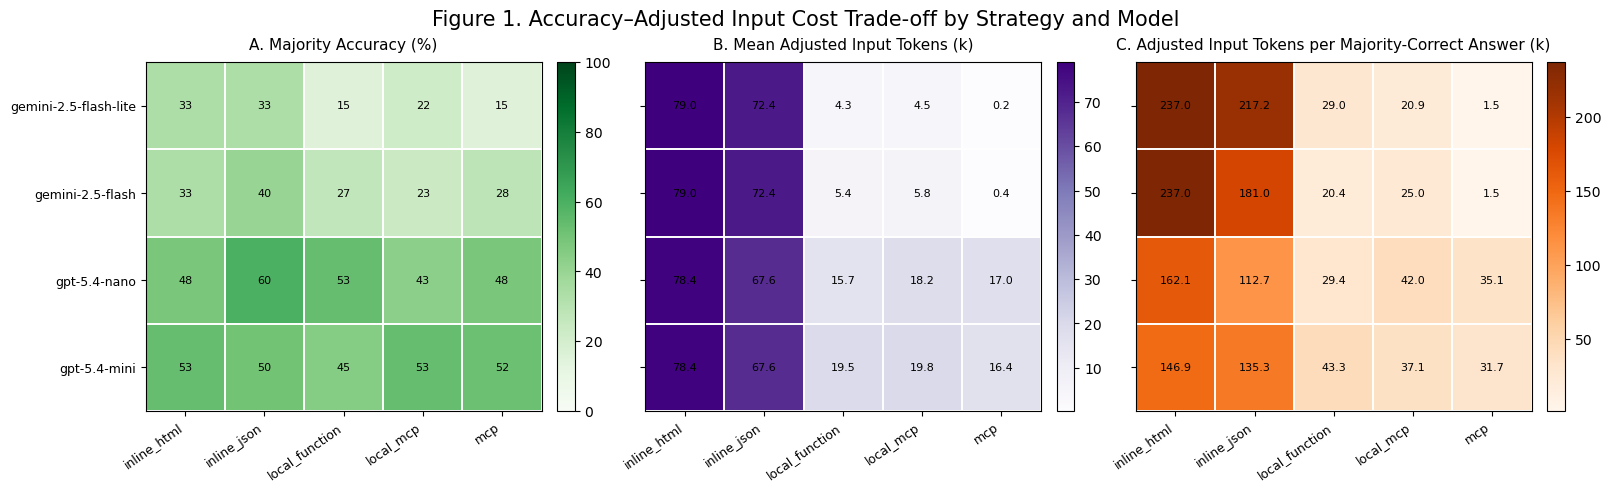

**Figure 1 interpretation.** This figure uses adjusted input tokens for all token-based panels. For Gemini native MCP, adjusted input tokens include both direct prompt tokens and `tool_use_prompt_token_count`, which prevents underestimating the input/context cost of Gemini MCP runs. Panel A shows majority accuracy, Panel B shows mean adjusted input tokens per run, and Panel C shows adjusted input tokens spent per majority-correct answer. Lower values in Panel C indicate better input-token efficiency among successful answers. Provider-reported total query tokens are still reported in Table 1 and should be used when discussing total provider cost.

In [7]:
# Figure 1:
# Accuracy–Adjusted Input Cost trade-off by strategy and model.
#
# This version intentionally uses adjusted input tokens for all token panels.
# Provider-reported total tokens remain available in Table 1 for total-cost analysis.

fig_df = runs.dropna(
    subset=["model", "effective_strategy", "query_input_tokens_adjusted"]
).copy()

fig_df["majority_correct_numeric"] = fig_df["majority_correct"].astype(float)

summary = (
    fig_df
    .groupby(["model", "effective_strategy"], as_index=False)
    .agg(
        Runs=("runId", "nunique"),
        Majority_Correct=("majority_correct_numeric", "sum"),
        Majority_Accuracy=("majority_correct_numeric", "mean"),
        Mean_Adjusted_Input_Tokens=("query_input_tokens_adjusted", "mean"),
        Total_Adjusted_Input_Tokens=("query_input_tokens_adjusted", "sum"),
        Mean_Query_Time_s=("query_duration_s", "mean"),
    )
)

summary["Majority_Accuracy_Pct"] = summary["Majority_Accuracy"] * 100
summary["Mean_Adjusted_Input_Tokens_k"] = summary["Mean_Adjusted_Input_Tokens"] / 1000
summary["Adjusted_Input_Tokens_per_Majority_Correct_k"] = (
    summary["Total_Adjusted_Input_Tokens"]
    / summary["Majority_Correct"].replace(0, np.nan)
    / 1000
)

strategy_order = [
    s for s in ["inline_html", "inline_json", "local_function", "local_mcp", "mcp"]
    if s in summary["effective_strategy"].unique()
]

preferred_model_order = [
    "gemini-2.5-flash-lite",
    "gemini-2.5-flash",
    "gpt-5.4-nano",
    "gpt-5.4-mini",
]

model_order = [m for m in preferred_model_order if m in summary["model"].unique()] + [
    m for m in sorted(summary["model"].unique()) if m not in preferred_model_order
]

def matrix(value_col):
    return (
        summary
        .pivot(index="model", columns="effective_strategy", values=value_col)
        .reindex(index=model_order, columns=strategy_order)
    )

matrices = [
    (
        "A. Majority Accuracy (%)",
        matrix("Majority_Accuracy_Pct"),
        lambda v: f"{v:.0f}",
        "Greens",
        0,
        100,
    ),
    (
        "B. Mean Adjusted Input Tokens (k)",
        matrix("Mean_Adjusted_Input_Tokens_k"),
        lambda v: f"{v:.1f}",
        "Purples",
        None,
        None,
    ),
    (
        "C. Adjusted Input Tokens per Majority-Correct Answer (k)",
        matrix("Adjusted_Input_Tokens_per_Majority_Correct_k"),
        lambda v: f"{v:.1f}",
        "Oranges",
        None,
        None,
    ),
]

def draw_heatmap(ax, title, data_matrix, fmt, cmap, vmin=None, vmax=None):
    data = data_matrix.to_numpy(dtype=float)
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")

    ax.set_title(title, fontsize=11, pad=9)
    ax.set_xticks(np.arange(data_matrix.shape[1]))
    ax.set_yticks(np.arange(data_matrix.shape[0]))

    ax.set_xticklabels(data_matrix.columns, rotation=35, ha="right", fontsize=9)
    ax.set_yticklabels(data_matrix.index, fontsize=9)

    ax.set_xticks(np.arange(-0.5, data_matrix.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, data_matrix.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.4)
    ax.tick_params(which="minor", bottom=False, left=False)

    for i in range(data_matrix.shape[0]):
        for j in range(data_matrix.shape[1]):
            value = data[i, j]
            text = "–" if np.isnan(value) else fmt(value)
            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=8,
                color="black",
            )

    return im

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.8),
    constrained_layout=True,
)

ims = []
for ax, spec in zip(axes, matrices):
    ims.append(draw_heatmap(ax, *spec))

# Only the first panel needs model labels.
axes[1].set_yticklabels([])
axes[2].set_yticklabels([])

for ax, im in zip(axes, ims):
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(
    "Figure 1. Accuracy–Adjusted Input Cost Trade-off by Strategy and Model",
    fontsize=15,
)

plt.show()

display(Markdown(
    "**Figure 1 interpretation.** This figure uses adjusted input tokens for all token-based panels. "
    "For Gemini native MCP, adjusted input tokens include both direct prompt tokens and `tool_use_prompt_token_count`, "
    "which prevents underestimating the input/context cost of Gemini MCP runs. "
    "Panel A shows majority accuracy, Panel B shows mean adjusted input tokens per run, and Panel C shows adjusted input tokens spent per majority-correct answer. "
    "Lower values in Panel C indicate better input-token efficiency among successful answers. "
    "Provider-reported total query tokens are still reported in Table 1 and should be used when discussing total provider cost."
))


## 7. Figure 2 — Query Execution Time by Strategy and Model


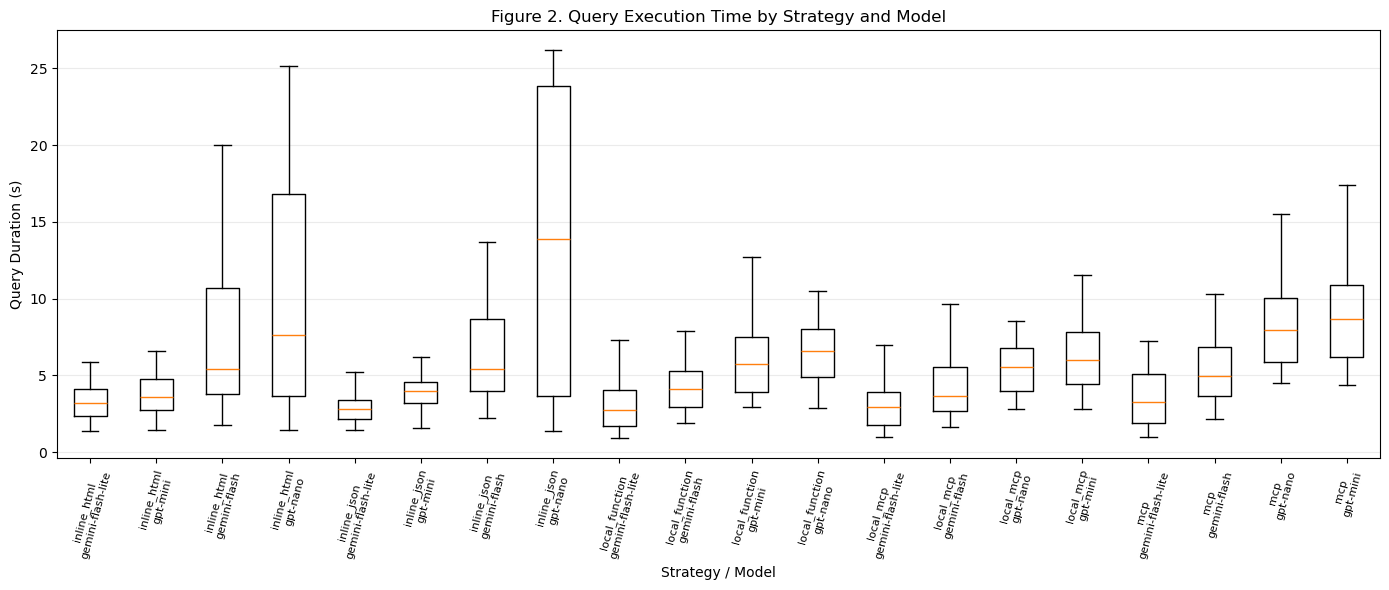

**Figure 2 interpretation.** The fastest strategy by median query time is **inline_json** (4.01s), while the slowest is **mcp** (5.99s).

In [8]:
box_df = runs.dropna(subset=["query_duration_s", "effective_strategy", "model"]).copy()
box_df["Strategy / Model"] = box_df["effective_strategy"] + "\n" + box_df["model"].str.replace("gemini-2.5-", "gemini-", regex=False).str.replace("gpt-5.4-", "gpt-", regex=False)
order = box_df.groupby(["effective_strategy", "model"])["query_duration_s"].median().reset_index().sort_values(["effective_strategy", "query_duration_s"])
labels = [f"{r.effective_strategy}\n{r.model.replace('gemini-2.5-', 'gemini-').replace('gpt-5.4-', 'gpt-')}" for r in order.itertuples()]
data = [box_df.loc[box_df["Strategy / Model"] == label, "query_duration_s"].values for label in labels]

fig, ax = plt.subplots(figsize=(14, 6))
ax.boxplot(data, tick_labels=labels, showfliers=False)
ax.set_title("Figure 2. Query Execution Time by Strategy and Model")
ax.set_xlabel("Strategy / Model")
ax.set_ylabel("Query Duration (s)")
ax.tick_params(axis="x", rotation=75, labelsize=8)
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

time_summary = runs.groupby("effective_strategy").agg(
    Median_Query_Time_s=("query_duration_s", "median"),
    Majority_Accuracy=("majority_correct", "mean"),
).reset_index().rename(columns={"effective_strategy": "Strategy"})
fastest = time_summary.sort_values("Median_Query_Time_s").iloc[0]
slowest = time_summary.sort_values("Median_Query_Time_s", ascending=False).iloc[0]
display(Markdown(
    f"**Figure 2 interpretation.** The fastest strategy by median query time is **{fastest['Strategy']}** ({fastest['Median_Query_Time_s']:.2f}s), "
    f"while the slowest is **{slowest['Strategy']}** ({slowest['Median_Query_Time_s']:.2f}s)."
))


## 8. Figure 3 — Judge Vote Distribution by Question, Tag, and Criterion

The right-side token annotations use mean **adjusted input tokens**, so Gemini native MCP input usage includes native tool-use prompt tokens.


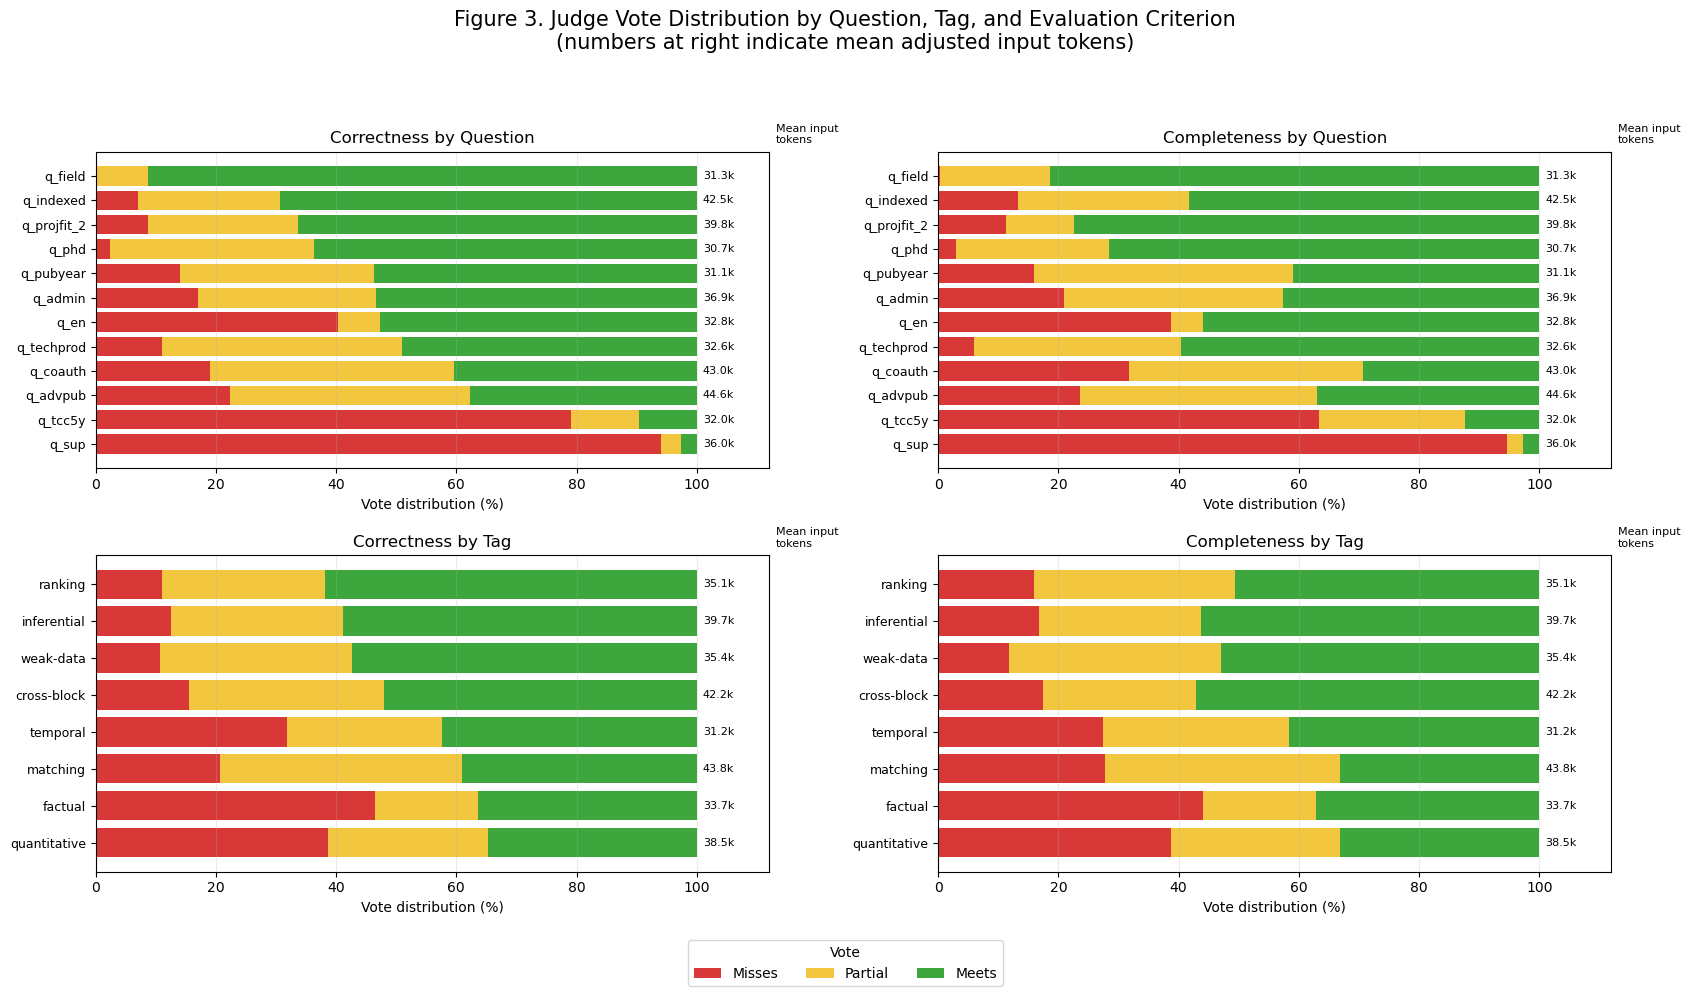

**Figure 3 interpretation.** The figure shows where judges classify answers as misses, partial, or meets. The token annotations use adjusted input tokens, so Gemini native MCP includes `tool_use_prompt_token_count`. Tag-level results are multi-label aggregates: one question may contribute to more than one tag.

In [9]:
run_meta = runs[["runId", "questionId", "questionTagsList", "query_input_tokens_adjusted"]].drop_duplicates("runId")
votes = judge_votes.merge(run_meta, on="runId", how="left", suffixes=("", "_run"))
if "questionId" not in votes.columns:
    for c in ["questionId_x", "questionId_y", "questionId_run"]:
        if c in votes.columns:
            votes["questionId"] = votes[c]
            break
if "questionId_run" in votes.columns:
    votes["questionId"] = votes["questionId"].fillna(votes["questionId_run"])

rating_order = ["misses", "partial", "meets"]
rating_colors = {"misses": "#d62728", "partial": "#f2c12e", "meets": "#2ca02c"}

def format_tokens(value):
    if pd.isna(value):
        return ""
    return f"{value/1000:.1f}k" if value >= 1000 else f"{value:.0f}"


def vote_distribution(df, group_col, rating_col, group_order):
    grouped = df.dropna(subset=[group_col, rating_col]).groupby([group_col, rating_col]).size().unstack(rating_col, fill_value=0).reindex(columns=rating_order, fill_value=0)
    grouped = grouped.reindex(group_order).fillna(0)
    return grouped.div(grouped.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100


def plot_distribution(ax, dist, title, token_map):
    labels = list(dist.index)
    y = np.arange(len(labels))
    left = np.zeros(len(labels))
    for rating in rating_order:
        values = dist[rating].values
        ax.barh(y, values, left=left, label=rating.capitalize(), color=rating_colors[rating], alpha=0.92)
        left += values
    ax.set_title(title, fontsize=12)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlim(0, 112)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.25)
    ax.set_xlabel("Vote distribution (%)")
    ax.text(1.01, 1.02, "Mean input\ntokens", transform=ax.transAxes, ha="left", va="bottom", fontsize=8)
    for i, label in enumerate(labels):
        ax.text(101.0, i, format_tokens(token_map.get(label, np.nan)), va="center", ha="left", fontsize=8)
    ax.set_xticks([0, 20, 40, 60, 80, 100])

question_tokens = runs.groupby("questionId")["query_input_tokens_adjusted"].mean().to_dict()
q_tmp = vote_distribution(votes, "questionId", "correctness_rating", sorted(votes["questionId"].dropna().unique()))
question_order = q_tmp.sort_values(["meets", "partial"], ascending=[False, False]).index.tolist()
question_correctness = vote_distribution(votes, "questionId", "correctness_rating", question_order)
question_completeness = vote_distribution(votes, "questionId", "completeness_rating", question_order)

tag_rows = []
for _, row in votes.iterrows():
    for tag in row.get("questionTagsList") or []:
        tag_rows.append({"Tag": tag, "correctness_rating": row.get("correctness_rating"), "completeness_rating": row.get("completeness_rating"), "runId": row.get("runId")})
tag_votes = pd.DataFrame(tag_rows)

run_tag_rows = []
for _, row in runs[["runId", "questionTagsList", "query_input_tokens_adjusted"]].drop_duplicates("runId").iterrows():
    for tag in row.get("questionTagsList") or []:
        run_tag_rows.append({"Tag": tag, "runId": row.get("runId"), "query_input_tokens_adjusted": row.get("query_input_tokens_adjusted")})
run_tags = pd.DataFrame(run_tag_rows)
tag_tokens = run_tags.groupby("Tag")["query_input_tokens_adjusted"].mean().to_dict()

t_tmp = vote_distribution(tag_votes, "Tag", "correctness_rating", sorted(tag_votes["Tag"].dropna().unique()))
tag_order = t_tmp.sort_values(["meets", "partial"], ascending=[False, False]).index.tolist()
tag_correctness = vote_distribution(tag_votes, "Tag", "correctness_rating", tag_order)
tag_completeness = vote_distribution(tag_votes, "Tag", "completeness_rating", tag_order)

fig, axes = plt.subplots(2, 2, figsize=(17, 10))
plot_distribution(axes[0, 0], question_correctness, "Correctness by Question", question_tokens)
plot_distribution(axes[0, 1], question_completeness, "Completeness by Question", question_tokens)
plot_distribution(axes[1, 0], tag_correctness, "Correctness by Tag", tag_tokens)
plot_distribution(axes[1, 1], tag_completeness, "Completeness by Tag", tag_tokens)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Vote", loc="lower center", ncol=3, frameon=True)
fig.suptitle("Figure 3. Judge Vote Distribution by Question, Tag, and Evaluation Criterion\n(numbers at right indicate mean adjusted input tokens)", fontsize=15, y=0.98)
plt.tight_layout(rect=[0, 0.06, 1, 0.94])
plt.show()

display(Markdown(
    "**Figure 3 interpretation.** The figure shows where judges classify answers as misses, partial, or meets. "
    "The token annotations use adjusted input tokens, so Gemini native MCP includes `tool_use_prompt_token_count`. "
    "Tag-level results are multi-label aggregates: one question may contribute to more than one tag."
))


## 9. Judge behavior


In [10]:
judge_behavior = (
    judge_votes
    .groupby("judgeId")
    .agg(
        Votes=("runId", "count"),
        Both_Criteria_Meet=("both_criteria_meet", "mean"),
        Correctness_Meets=("correctness_meets", "mean"),
        Completeness_Meets=("completeness_meets", "mean"),
        Mean_Duration_s=("durationMs", lambda s: pd.to_numeric(s, errors="coerce").mean() / 1000.0),
    )
    .reset_index()
    .rename(columns={
        "judgeId": "Judge",
        "Both_Criteria_Meet": "Both Criteria Meet Rate",
        "Correctness_Meets": "Correctness Meets Rate",
        "Completeness_Meets": "Completeness Meets Rate",
        "Mean_Duration_s": "Mean Judge Duration (s)",
    })
)

display(judge_behavior.style.format({
    "Both Criteria Meet Rate": "{:.1%}".format,
    "Correctness Meets Rate": "{:.1%}".format,
    "Completeness Meets Rate": "{:.1%}".format,
    "Mean Judge Duration (s)": "{:.2f}".format,
}))

most_permissive = judge_behavior.sort_values("Both Criteria Meet Rate", ascending=False).iloc[0]
most_conservative = judge_behavior.sort_values("Both Criteria Meet Rate").iloc[0]
display(Markdown(
    f"**Judge behavior interpretation.** The most permissive judge is **{most_permissive['Judge']}** "
    f"({most_permissive['Both Criteria Meet Rate']:.1%}), while the most conservative is **{most_conservative['Judge']}** "
    f"({most_conservative['Both Criteria Meet Rate']:.1%}). This supports reporting both majority and unanimous accuracy."
))


,Judge,Votes,Both Criteria Meet Rate,Correctness Meets Rate,Completeness Meets Rate,Mean Judge Duration (s)
0,juiz-claude,1200,29.8%,44.7%,36.2%,12.11
1,juiz-gemini,1200,62.8%,67.2%,67.0%,2.97
2,juiz-gpt,1200,31.8%,35.5%,39.2%,3.28


**Judge behavior interpretation.** The most permissive judge is **juiz-gemini** (62.8%), while the most conservative is **juiz-claude** (29.8%). This supports reporting both majority and unanimous accuracy.

## 10. Summary and exports

Key reporting choices:

1. Use **query total tokens** for provider-cost efficiency.
2. Use **adjusted input tokens** for input/context-size analysis, especially for Gemini native MCP.
3. Exclude evaluation tokens from answer-generation cost.
4. Report majority and unanimous accuracy together.
5. Interpret tool usage with query traces, not only aggregate counters.


In [11]:
EXPORT_DIR = BASE_DIR / "analysis_exports"
EXPORT_DIR.mkdir(exist_ok=True)

cost_table_display.to_csv(EXPORT_DIR / "table_1_cost_per_correct_answer.csv", index=False)
question_table_display.to_csv(EXPORT_DIR / "table_2_question_level_accuracy.csv", index=False)
tool_table_display.to_csv(EXPORT_DIR / "table_3_observed_tool_usage.csv", index=False)
audit_summary.to_csv(EXPORT_DIR / "gemini_mcp_token_audit.csv", index=False)

if "call_source_summary" in globals():
    call_source_summary.to_csv(EXPORT_DIR / "observed_call_source_summary.csv", index=False)
if "source_breakdown" in globals() and not source_breakdown.empty:
    source_breakdown.to_csv(EXPORT_DIR / "observed_call_source_breakdown.csv", index=False)
if "observed_calls_by_run" in globals() and not observed_calls_by_run.empty:
    observed_calls_by_run.to_csv(EXPORT_DIR / "observed_tool_calls_by_run_used.csv", index=False)
if "observed_calls_long" in globals() and not observed_calls_long.empty:
    observed_calls_long.to_csv(EXPORT_DIR / "observed_tool_calls_long_used.csv", index=False)

print(f"Exported analysis tables to {EXPORT_DIR.resolve()}")

Exported analysis tables to /home/michel/repos/doutorado/contextbench-lattes/experiments/baseline_001/analysis_exports


## 11. Scatter / Pareto — accuracy, token cost, and latency

This section adds the scatter/Pareto view suggested for the article. The plot summarizes the trade-off between answer quality and input/context cost.

- **x-axis**: adjusted input tokens per majority-correct answer. Lower is better.
- **y-axis**: majority accuracy. Higher is better.
- **point size**: median query time. Smaller points are faster.
- **dashed line**: Pareto frontier, considering lower cost and higher accuracy.

The strategy-level plot is easier to use in the paper, while the model-strategy plot is useful for diagnosing which models drive each strategy result.

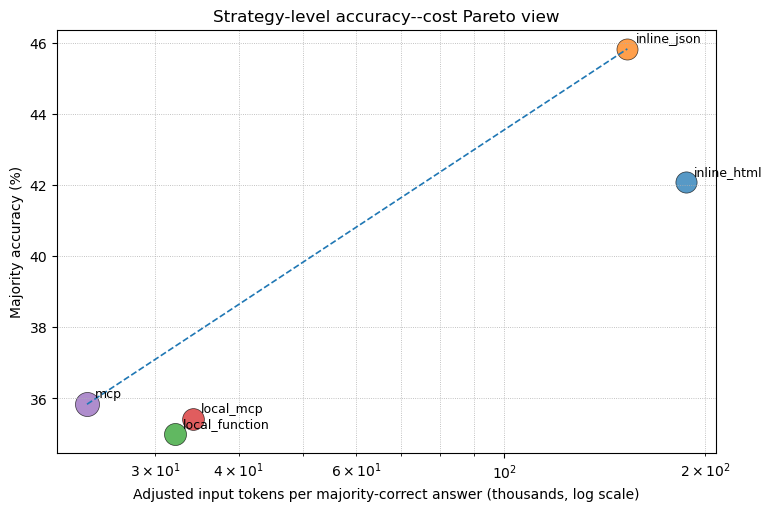

,effective_strategy,Runs,Majority_Correct,Majority_Accuracy,Adjusted_Input_Tokens,Median_Query_Time_s,Mean_Query_Total_Tokens,Majority_Accuracy_Pct,Adjusted_Input_Tokens_per_Majority_Correct_k
4,mcp,240,86,0.358333,2038340,5.9870,9003.570833,35.833333,23.701628
2,local_function,240,84,0.350000,2696380,4.6120,11728.316667,35.000000,32.099762
3,local_mcp,240,85,0.354167,2901288,4.4470,12550.366667,35.416667,34.132800
1,inline_json,240,110,0.458333,16806612,4.0110,70557.733333,45.833333,152.787382
0,inline_html,240,101,0.420833,18881768,4.0875,79282.362500,42.083333,186.948198


In [12]:
def pareto_frontier(df, x_col, y_col):
    tmp = df.dropna(subset=[x_col, y_col]).copy()
    points = tmp[[x_col, y_col]].to_numpy(dtype=float)
    keep = []
    for i, (x, y) in enumerate(points):
        dominated = False
        for j, (x2, y2) in enumerate(points):
            if i == j:
                continue
            if (x2 <= x and y2 >= y) and (x2 < x or y2 > y):
                dominated = True
                break
        if not dominated:
            keep.append(i)
    return tmp.iloc[keep].sort_values(x_col)

pareto_strategy = (
    runs
    .groupby("effective_strategy", as_index=False)
    .agg(
        Runs=("runId", "count"),
        Majority_Correct=("majority_correct", "sum"),
        Majority_Accuracy=("majority_correct", "mean"),
        Adjusted_Input_Tokens=("query_input_tokens_adjusted", "sum"),
        Median_Query_Time_s=("query_duration_s", "median"),
        Mean_Query_Total_Tokens=("query_total_tokens", "mean"),
    )
)
pareto_strategy["Majority_Accuracy_Pct"] = pareto_strategy["Majority_Accuracy"] * 100
pareto_strategy["Adjusted_Input_Tokens_per_Majority_Correct_k"] = (
    pareto_strategy["Adjusted_Input_Tokens"]
    / pareto_strategy["Majority_Correct"].replace(0, np.nan)
    / 1000
)
frontier_strategy = pareto_frontier(
    pareto_strategy,
    "Adjusted_Input_Tokens_per_Majority_Correct_k",
    "Majority_Accuracy_Pct",
)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for _, row in pareto_strategy.iterrows():
    ax.scatter(
        row["Adjusted_Input_Tokens_per_Majority_Correct_k"],
        row["Majority_Accuracy_Pct"],
        s=90 + row["Median_Query_Time_s"] * 35,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.5,
    )
    ax.annotate(
        row["effective_strategy"],
        (row["Adjusted_Input_Tokens_per_Majority_Correct_k"], row["Majority_Accuracy_Pct"]),
        textcoords="offset points",
        xytext=(6, 5),
        fontsize=9,
    )

ax.plot(
    frontier_strategy["Adjusted_Input_Tokens_per_Majority_Correct_k"],
    frontier_strategy["Majority_Accuracy_Pct"],
    linestyle="--",
    linewidth=1.2,
)
ax.set_xscale("log")
ax.set_xlabel("Adjusted input tokens per majority-correct answer (thousands, log scale)")
ax.set_ylabel("Majority accuracy (%)")
ax.set_title("Strategy-level accuracy--cost Pareto view")
ax.grid(True, which="both", linestyle=":", linewidth=0.6)
plt.show()

display(pareto_strategy.sort_values("Adjusted_Input_Tokens_per_Majority_Correct_k"))

### Model-strategy Pareto view

This version keeps one point per `(model, effective_strategy)` pair. It is more detailed and helps identify whether a strategy-level result is driven by a specific provider/model combination.

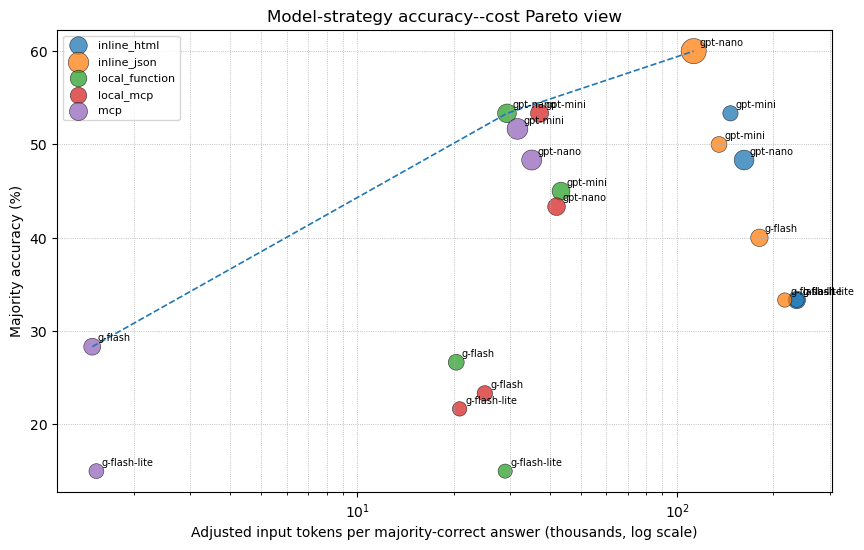

,effective_strategy,model,Runs,Majority_Correct,Majority_Accuracy,Adjusted_Input_Tokens,Median_Query_Time_s,Mean_Query_Total_Tokens,Majority_Accuracy_Pct,Adjusted_Input_Tokens_per_Majority_Correct_k
16,mcp,gemini-2.5-flash,60,17,0.283333,25146,4.9380,1112.316667,28.333333,1.479176
17,mcp,gemini-2.5-flash-lite,60,9,0.150000,13716,3.2455,312.000000,15.000000,1.524000
8,local_function,gemini-2.5-flash,60,16,0.266667,325939,4.0885,6140.916667,26.666667,20.371188
13,local_mcp,gemini-2.5-flash-lite,60,13,0.216667,271344,2.9235,4659.433333,21.666667,20.872615
12,local_mcp,gemini-2.5-flash,60,14,0.233333,350497,3.6840,6426.850000,23.333333,25.035500
9,local_function,gemini-2.5-flash-lite,60,9,0.150000,260862,2.7165,4445.933333,15.000000,28.984667
11,local_function,gpt-5.4-nano,60,32,0.533333,939504,6.5765,16115.200000,53.333333,29.359500
18,mcp,gpt-5.4-mini,60,31,0.516667,981668,8.6905,17163.800000,51.666667,31.666710
19,mcp,gpt-5.4-nano,60,29,0.483333,1017810,7.9305,17426.166667,48.333333,35.096897
14,local_mcp,gpt-5.4-mini,60,32,0.533333,1188365,6.0105,20518.450000,53.333333,37.136406


In [13]:
pareto_model_strategy = (
    runs
    .groupby(["effective_strategy", "model"], as_index=False)
    .agg(
        Runs=("runId", "count"),
        Majority_Correct=("majority_correct", "sum"),
        Majority_Accuracy=("majority_correct", "mean"),
        Adjusted_Input_Tokens=("query_input_tokens_adjusted", "sum"),
        Median_Query_Time_s=("query_duration_s", "median"),
        Mean_Query_Total_Tokens=("query_total_tokens", "mean"),
    )
)
pareto_model_strategy["Majority_Accuracy_Pct"] = pareto_model_strategy["Majority_Accuracy"] * 100
pareto_model_strategy["Adjusted_Input_Tokens_per_Majority_Correct_k"] = (
    pareto_model_strategy["Adjusted_Input_Tokens"]
    / pareto_model_strategy["Majority_Correct"].replace(0, np.nan)
    / 1000
)
frontier_model_strategy = pareto_frontier(
    pareto_model_strategy,
    "Adjusted_Input_Tokens_per_Majority_Correct_k",
    "Majority_Accuracy_Pct",
)

fig, ax = plt.subplots(figsize=(10, 6))
for strategy_name, group in pareto_model_strategy.groupby("effective_strategy"):
    ax.scatter(
        group["Adjusted_Input_Tokens_per_Majority_Correct_k"],
        group["Majority_Accuracy_Pct"],
        s=50 + group["Median_Query_Time_s"] * 20,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.4,
        label=strategy_name,
    )
    for _, row in group.iterrows():
        short_model = (
            str(row["model"])
            .replace("gemini-2.5-", "g-")
            .replace("gpt-5.4-", "gpt-")
        )
        ax.annotate(
            short_model,
            (row["Adjusted_Input_Tokens_per_Majority_Correct_k"], row["Majority_Accuracy_Pct"]),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=7,
        )

ax.plot(
    frontier_model_strategy["Adjusted_Input_Tokens_per_Majority_Correct_k"],
    frontier_model_strategy["Majority_Accuracy_Pct"],
    linestyle="--",
    linewidth=1.2,
)
ax.set_xscale("log")
ax.set_xlabel("Adjusted input tokens per majority-correct answer (thousands, log scale)")
ax.set_ylabel("Majority accuracy (%)")
ax.set_title("Model-strategy accuracy--cost Pareto view")
ax.grid(True, which="both", linestyle=":", linewidth=0.6)
ax.legend(fontsize=8)
plt.show()

display(pareto_model_strategy.sort_values("Adjusted_Input_Tokens_per_Majority_Correct_k"))

## Article table — model × strategy split

This section builds the compact table intended for the paper. It now uses `observed_tool_calls_by_run.csv` for the call-behavior column, so remote MCP calls are counted from provider-native trace evidence instead of only from `metricsSummary.toolCalls`.

In [14]:
# Compact article table: model × strategy, split by provider family.
# This cell uses the trace-derived `observed_tool_calls` column created above.

ARTICLE_STRATEGY_ORDER = ["inline_html", "inline_json", "local_function", "local_mcp", "mcp"]
ARTICLE_MODEL_ORDER = ["gpt1", "gpt2", "gemini1", "gemini2"]

MODEL_LABELS = {
    "gpt1": "GPT-Nano",
    "gpt2": "GPT-Mini",
    "gemini1": "Gemini-Lite",
    "gemini2": "Gemini-Flash",
    "gpt-5.4-nano": "GPT-Nano",
    "gpt-5.4-mini": "GPT-Mini",
    "gemini-2.5-flash-lite": "Gemini-Lite",
    "gemini-2.5-flash": "Gemini-Flash",
}

MODEL_FAMILY = {
    "gpt1": "OpenAI",
    "gpt2": "OpenAI",
    "gemini1": "Gemini",
    "gemini2": "Gemini",
    "gpt-5.4-nano": "OpenAI",
    "gpt-5.4-mini": "OpenAI",
    "gemini-2.5-flash-lite": "Gemini",
    "gemini-2.5-flash": "Gemini",
}

MODEL_ORDER = {
    "gpt1": 1,
    "gpt2": 2,
    "gemini1": 3,
    "gemini2": 4,
    "gpt-5.4-nano": 1,
    "gpt-5.4-mini": 2,
    "gemini-2.5-flash-lite": 3,
    "gemini-2.5-flash": 4,
}

CFG_LABELS = {
    "inline_html": "I-HTML",
    "inline_json": "I-JSON",
    "local_function": "Func.",
    "local_mcp": "L-MCP",
    "mcp": "R-MCP",
}

# If this cell is run without the tool-usage section, fall back to aggregate metrics.
# This fallback is not recommended for the paper because it undercounts remote MCP calls.
if "observed_tool_calls" not in runs.columns:
    runs = runs.copy()
    runs["observed_tool_calls"] = pd.to_numeric(runs.get("aggregate_tool_calls", 0), errors="coerce").fillna(0)
    runs["used_tool"] = runs["observed_tool_calls"] > 0

article_base = runs.copy()
# Use wall-clock query duration for the compact article table, matching timing.durationMs.
if "query_wall_duration_s" not in article_base.columns:
    article_base["query_wall_duration_s"] = pd.to_numeric(article_base.get("timing.durationMs"), errors="coerce") / 1000.0
article_base["majority_correct_num"] = article_base["majority_correct"].astype(float)
article_base["unanimous_correct_num"] = article_base["unanimous_correct"].astype(float)
article_base["model_key"] = article_base["modelId"].where(article_base["modelId"].notna(), article_base["model"])
article_base["model_order"] = article_base["model_key"].map(MODEL_ORDER).fillna(999).astype(int)
article_base["strategy_order"] = article_base["effective_strategy"].map({s: i for i, s in enumerate(ARTICLE_STRATEGY_ORDER)})

article_model_strategy = (
    article_base
    .groupby(["model_key", "model", "model_order", "effective_strategy", "strategy_order"], as_index=False)
    .agg(
        Runs=("runId", "count"),
        Majority_Accuracy=("majority_correct_num", "mean"),
        Unanimous_Accuracy=("unanimous_correct_num", "mean"),
        Mean_Total_Tokens=("query_total_tokens", "mean"),
        Mean_Adjusted_Input_Tokens=("query_input_tokens_adjusted", "mean"),
        Median_Query_Time_s=("query_wall_duration_s", "median"),
        Mean_Observed_Calls=("observed_tool_calls", "mean"),
    )
)

article_model_strategy["Family"] = article_model_strategy["model_key"].map(MODEL_FAMILY).fillna(
    article_model_strategy["model"].map(MODEL_FAMILY)
)
article_model_strategy["Model"] = article_model_strategy["model_key"].map(MODEL_LABELS).fillna(
    article_model_strategy["model"].map(MODEL_LABELS)
).fillna(article_model_strategy["model_key"])
article_model_strategy["Cfg."] = article_model_strategy["effective_strategy"].map(CFG_LABELS)

# Compact table for the article.
article_compact = (
    article_model_strategy
    .sort_values(["model_order", "strategy_order"])
    [[
        "Family", "Model", "Cfg.", "Runs", "Majority_Accuracy", "Unanimous_Accuracy",
        "Mean_Total_Tokens", "Median_Query_Time_s", "Mean_Observed_Calls",
    ]]
    .rename(columns={
        "Majority_Accuracy": "Maj.",
        "Unanimous_Accuracy": "Unan.",
        "Mean_Total_Tokens": "Tok.",
        "Median_Query_Time_s": "Sec.",
        "Mean_Observed_Calls": "Obs. calls",
    })
)

# Expanded table for checking token and call accounting.
article_expanded = (
    article_model_strategy
    .sort_values(["model_order", "strategy_order"])
    [[
        "Family", "Model", "Cfg.", "Runs", "Majority_Accuracy", "Unanimous_Accuracy",
        "Mean_Total_Tokens", "Mean_Adjusted_Input_Tokens", "Median_Query_Time_s", "Mean_Observed_Calls",
    ]]
    .rename(columns={
        "Majority_Accuracy": "Majority Accuracy",
        "Unanimous_Accuracy": "Unanimous Accuracy",
        "Mean_Total_Tokens": "Mean Total Tokens",
        "Mean_Adjusted_Input_Tokens": "Mean Adjusted Input Tokens",
        "Median_Query_Time_s": "Median Time (s)",
        "Mean_Observed_Calls": "Mean Observed Calls",
    })
)

# Store machine-readable outputs in both the working directory and the experiment export directory.
article_compact.to_csv("article_model_strategy_compact.csv", index=False)
article_expanded.to_csv("article_model_strategy_expanded.csv", index=False)
try:
    article_compact.to_csv(EXPORT_DIR / "article_model_strategy_compact.csv", index=False)
    article_expanded.to_csv(EXPORT_DIR / "article_model_strategy_expanded.csv", index=False)
except NameError:
    pass

# Display side-by-side in the notebook.
openai_compact = article_compact[article_compact["Family"] == "OpenAI"].drop(columns="Family")
gemini_compact = article_compact[article_compact["Family"] == "Gemini"].drop(columns="Family")

fmt_compact = {
    "Maj.": "{:.1%}",
    "Unan.": "{:.1%}",
    "Tok.": lambda x: f"{x/1000:.1f}k",
    "Sec.": "{:.2f}",
    "Obs. calls": "{:.2f}",
}

display(Markdown("### Compact article table — OpenAI"))
display(openai_compact.style.format(fmt_compact))

display(Markdown("### Compact article table — Gemini"))
display(gemini_compact.style.format(fmt_compact))

display(Markdown("### Expanded table for checking token and observed-call accounting"))
display(article_expanded.style.format({
    "Majority Accuracy": "{:.1%}",
    "Unanimous Accuracy": "{:.1%}",
    "Mean Total Tokens": "{:,.0f}",
    "Mean Adjusted Input Tokens": "{:,.0f}",
    "Median Time (s)": "{:.2f}",
    "Mean Observed Calls": "{:.2f}",
}))

### Compact article table — OpenAI

,Model,Cfg.,Runs,Maj.,Unan.,Tok.,Sec.,Obs. calls
10,GPT-Nano,I-HTML,60,48.3%,30.0%,78.7k,8.50,0.00
11,GPT-Nano,I-JSON,60,60.0%,30.0%,67.9k,13.50,0.00
12,GPT-Nano,Func.,60,53.3%,33.3%,16.1k,7.00,1.42
13,GPT-Nano,L-MCP,60,43.3%,28.3%,18.6k,5.00,1.40
14,GPT-Nano,R-MCP,60,48.3%,28.3%,17.4k,8.00,0.00
15,GPT-Mini,I-HTML,60,53.3%,28.3%,78.8k,4.00,0.00
16,GPT-Mini,I-JSON,60,50.0%,23.3%,68.1k,4.00,0.00
17,GPT-Mini,Func.,60,45.0%,25.0%,20.2k,6.00,1.83
18,GPT-Mini,L-MCP,60,53.3%,30.0%,20.5k,6.00,1.88
19,GPT-Mini,R-MCP,60,51.7%,20.0%,17.2k,9.00,0.00


### Compact article table — Gemini

,Model,Cfg.,Runs,Maj.,Unan.,Tok.,Sec.,Obs. calls
0,Gemini-Lite,I-HTML,60,33.3%,23.3%,79.2k,3.00,0.00
1,Gemini-Lite,I-JSON,60,33.3%,18.3%,72.5k,3.00,0.00
2,Gemini-Lite,Func.,60,15.0%,5.0%,4.4k,3.00,0.87
3,Gemini-Lite,L-MCP,60,21.7%,5.0%,4.7k,3.00,1.05
4,Gemini-Lite,R-MCP,60,15.0%,3.3%,0.3k,3.00,0.00
5,Gemini-Flash,I-HTML,60,33.3%,23.3%,80.5k,5.50,0.00
6,Gemini-Flash,I-JSON,60,40.0%,26.7%,73.7k,5.00,0.00
7,Gemini-Flash,Func.,60,26.7%,11.7%,6.1k,4.00,0.78
8,Gemini-Flash,L-MCP,60,23.3%,6.7%,6.4k,4.00,0.82
9,Gemini-Flash,R-MCP,60,28.3%,6.7%,1.1k,5.00,0.00


### Expanded table for checking token and observed-call accounting

,Family,Model,Cfg.,Runs,Majority Accuracy,Unanimous Accuracy,Mean Total Tokens,Mean Adjusted Input Tokens,Median Time (s),Mean Observed Calls
10,OpenAI,GPT-Nano,I-HTML,60,48.3%,30.0%,"78,655","78,354",8.50,0.00
11,OpenAI,GPT-Nano,I-JSON,60,60.0%,30.0%,"67,943","67,647",13.50,0.00
12,OpenAI,GPT-Nano,Func.,60,53.3%,33.3%,"16,115","15,658",7.00,1.42
13,OpenAI,GPT-Nano,L-MCP,60,43.3%,28.3%,"18,597","18,185",5.00,1.40
14,OpenAI,GPT-Nano,R-MCP,60,48.3%,28.3%,"17,426","16,964",8.00,0.00
15,OpenAI,GPT-Mini,I-HTML,60,53.3%,28.3%,"78,792","78,354",4.00,0.00
16,OpenAI,GPT-Mini,I-JSON,60,50.0%,23.3%,"68,127","67,647",4.00,0.00
17,OpenAI,GPT-Mini,Func.,60,45.0%,25.0%,"20,211","19,501",6.00,1.83
18,OpenAI,GPT-Mini,L-MCP,60,53.3%,30.0%,"20,518","19,806",6.00,1.88
19,OpenAI,GPT-Mini,R-MCP,60,51.7%,20.0%,"17,164","16,361",9.00,0.00


### Current compact values computed from `baseline_001`

Run the cell above to display the current OpenAI and Gemini tables. The `Obs. calls` column is now computed from the trace-derived `observed_tool_calls_by_run.csv` file when available. This is the recommended value for the article because it includes provider-native MCP evidence for remote MCP runs.

### LaTeX snippet for the paper

The following cell exports `article_model_strategy_table.tex` and prints the corresponding table.

In [15]:
# Generate a LaTeX table snippet matching the article layout.

def _fmt_pct(x):
    return f"{100*x:.1f}"

def _fmt_tok_k(x):
    return f"{x/1000:.1f}k"

def _fmt_float(x):
    return f"{x:.2f}"

def _latex_escape(s):
    return str(s).replace("_", r"\_")

def _latex_rows(df):
    lines = []
    previous_model = None
    for _, row in df.iterrows():
        model = row["Model"] if row["Model"] != previous_model else ""
        previous_model = row["Model"]
        lines.append(
            f"{_latex_escape(model)} & {_latex_escape(row['Cfg.'])} & "
            f"{_fmt_pct(row['Maj.'])} & {_fmt_pct(row['Unan.'])} & "
            f"{_fmt_tok_k(row['Tok.'])} & {_fmt_float(row['Sec.'])} & {_fmt_float(row['Obs. calls'])} \\\\"
        )
    return "\n".join(lines)

openai_latex_rows = _latex_rows(openai_compact)
gemini_latex_rows = _latex_rows(gemini_compact)

latex_table = f"""
\\begin{{table*}}[t]
\\centering
\\caption{{Effectiveness and execution efficiency by answering model and context provisioning configuration.}}
\\label{{tab:strategy-model-results}}
\\scriptsize
\\setlength{{\\tabcolsep}}{{2.5pt}}
\\renewcommand{{\\arraystretch}}{{1.08}}

\\begin{{minipage}}[t]{{0.49\\textwidth}}
\\centering
\\textbf{{(a) OpenAI answering models}}
\\vspace{{0.25em}}

\\begin{{tabular}}{{@{{}}llrrrrr@{{}}}}
\\toprule
Model & Cfg. & Maj. & Unan. & Tok. & Sec. & Obs. \\\\
\\midrule
{openai_latex_rows}
\\bottomrule
\\end{{tabular}}
\\end{{minipage}}
\\hfill
\\begin{{minipage}}[t]{{0.49\\textwidth}}
\\centering
\\textbf{{(b) Gemini answering models}}
\\vspace{{0.25em}}

\\begin{{tabular}}{{@{{}}llrrrrr@{{}}}}
\\toprule
Model & Cfg. & Maj. & Unan. & Tok. & Sec. & Obs. \\\\
\\midrule
{gemini_latex_rows}
\\bottomrule
\\end{{tabular}}
\\end{{minipage}}

\\vspace{{0.5em}}
\\footnotesize
Each row aggregates 60 answer-generation runs. Maj. and Unan. are majority and unanimous accuracy, respectively, computed from the three judges and requiring both correctness and completeness to be rated as \\emph{{meets}}. Tok. is the mean total query-phase token consumption, excluding evaluation tokens. Sec. is the median query duration in seconds. Obs. is the mean number of observed operation calls. For local function calling and local MCP, observed calls come from benchmark-controlled tool traces; for remote MCP, they come from provider-native MCP evidence in the trace-derived call CSV. I-HTML = inline HTML; I-JSON = inline JSON; Func. = local function calling; L-MCP = local MCP; R-MCP = remote MCP.
\\end{{table*}}
""".strip()

with open("article_model_strategy_table.tex", "w", encoding="utf-8") as f:
    f.write(latex_table + "\n")

try:
    with open(EXPORT_DIR / "article_model_strategy_table.tex", "w", encoding="utf-8") as f:
        f.write(latex_table + "\n")
except NameError:
    pass

print(latex_table)

\begin{table*}[t]
\centering
\caption{Effectiveness and execution efficiency by answering model and context provisioning configuration.}
\label{tab:strategy-model-results}
\scriptsize
\setlength{\tabcolsep}{2.5pt}
\renewcommand{\arraystretch}{1.08}

\begin{minipage}[t]{0.49\textwidth}
\centering
\textbf{(a) OpenAI answering models}
\vspace{0.25em}

\begin{tabular}{@{}llrrrrr@{}}
\toprule
Model & Cfg. & Maj. & Unan. & Tok. & Sec. & Obs. \\
\midrule
GPT-Nano & I-HTML & 48.3 & 30.0 & 78.7k & 8.50 & 0.00 \\
 & I-JSON & 60.0 & 30.0 & 67.9k & 13.50 & 0.00 \\
 & Func. & 53.3 & 33.3 & 16.1k & 7.00 & 1.42 \\
 & L-MCP & 43.3 & 28.3 & 18.6k & 5.00 & 1.40 \\
 & R-MCP & 48.3 & 28.3 & 17.4k & 8.00 & 0.00 \\
GPT-Mini & I-HTML & 53.3 & 28.3 & 78.8k & 4.00 & 0.00 \\
 & I-JSON & 50.0 & 23.3 & 68.1k & 4.00 & 0.00 \\
 & Func. & 45.0 & 25.0 & 20.2k & 6.00 & 1.83 \\
 & L-MCP & 53.3 & 30.0 & 20.5k & 6.00 & 1.88 \\
 & R-MCP & 51.7 & 20.0 & 17.2k & 9.00 & 0.00 \\
\bottomrule
\end{tabular}
\end{minipage}
\hfill

## Article figures

The following cells regenerate the main article figures directly from the notebook data.
They assume the `runs` dataframe has already been created by the earlier sections of this notebook.

Figures generated:
- `rq3_question_strategy_heatmap_muted.pdf/png`
- `rq2_latency_boxplot_strategy.pdf/png`
- `rq2_pareto_latency_improved.pdf/png`
- `rq3_question_difficulty_disagreement.pdf/png`

All files are written to `/mnt/data/article_figures_from_notebook/` by default.


In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

ARTICLE_FIGURES_DIR = Path("tmp/article_figures_from_notebook")
ARTICLE_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CFG_ORDER = ["I-HTML", "I-JSON", "Func.", "L-MCP", "R-MCP"]
QUESTION_ORDER = [
    "q_field",
    "q_projfit_2",
    "q_indexed",
    "q_en",
    "q_techprod",
    "q_phd",
    "q_admin",
    "q_pubyear",
    "q_advpub",
    "q_coauth",
    "q_tcc5y",
    "q_sup",
]

# Build canonical article labels if they do not exist yet.
def _cfg_label_from_row(row):
    strategy = row.get("strategy")
    fmt = row.get("format")
    if strategy == "inline" and fmt == "html":
        return "I-HTML"
    if strategy == "inline" and fmt == "json":
        return "I-JSON"
    if strategy == "local_function":
        return "Func."
    if strategy == "local_mcp":
        return "L-MCP"
    if strategy == "mcp":
        return "R-MCP"
    return f"{strategy}_{fmt}"

if "Cfg." not in runs.columns:
    runs["Cfg."] = runs.apply(_cfg_label_from_row, axis=1)

# Normalize duration and token columns if needed.
if "durationS" not in runs.columns:
    if "query_duration_s" in runs.columns:
        runs["durationS"] = runs["query_duration_s"]
    else:
        def _duration_from_row(r):
            timing = r.get("timing")
            if isinstance(timing, dict):
                value = timing.get("durationMs")
                if value is not None:
                    return float(value) / 1000.0
            return np.nan
        runs["durationS"] = runs.apply(_duration_from_row, axis=1)

if "queryTokens" not in runs.columns:
    if "query_total_tokens" in runs.columns:
        runs["queryTokens"] = runs["query_total_tokens"]
    else:
        def _tokens_from_row(r):
            usage = r.get("usage")
            if isinstance(usage, dict):
                value = usage.get("totalTokens")
                if value is not None:
                    return float(value)
            metrics = r.get("metricsSummary")
            if isinstance(metrics, dict):
                value = metrics.get("totalTokens")
                if value is not None:
                    return float(value)
            return np.nan
        runs["queryTokens"] = runs.apply(_tokens_from_row, axis=1)

# Full disagreement if not available yet.
if "full_disagreement" not in runs.columns:
    if "any_full_disagree" in runs.columns:
        runs["full_disagreement"] = runs["any_full_disagree"]
    else:
        runs["full_disagreement"] = False

print("Figures will be written to:", ARTICLE_FIGURES_DIR)
display(runs[["runId", "Cfg.", "questionId", "majority_correct", "unanimous_correct", "queryTokens", "durationS"]].head())


Figures will be written to: tmp/article_figures_from_notebook


,runId,Cfg.,questionId,majority_correct,unanimous_correct,queryTokens,durationS
0,18c128475a,Func.,q_projfit_2,False,False,992,1.705
1,6a0689d3ca,Func.,q_tcc5y,False,False,11981,2.672
2,02b094e6d4,Func.,q_phd,True,True,1948,9.348
3,c307b9dc52,Func.,q_phd,True,False,2597,4.472
4,48351c341d,Func.,q_phd,False,False,2856,4.559


### Generate article figures

This cell writes the PDF and PNG versions of the heatmap, latency boxplot, Pareto view, and disagreement chart.


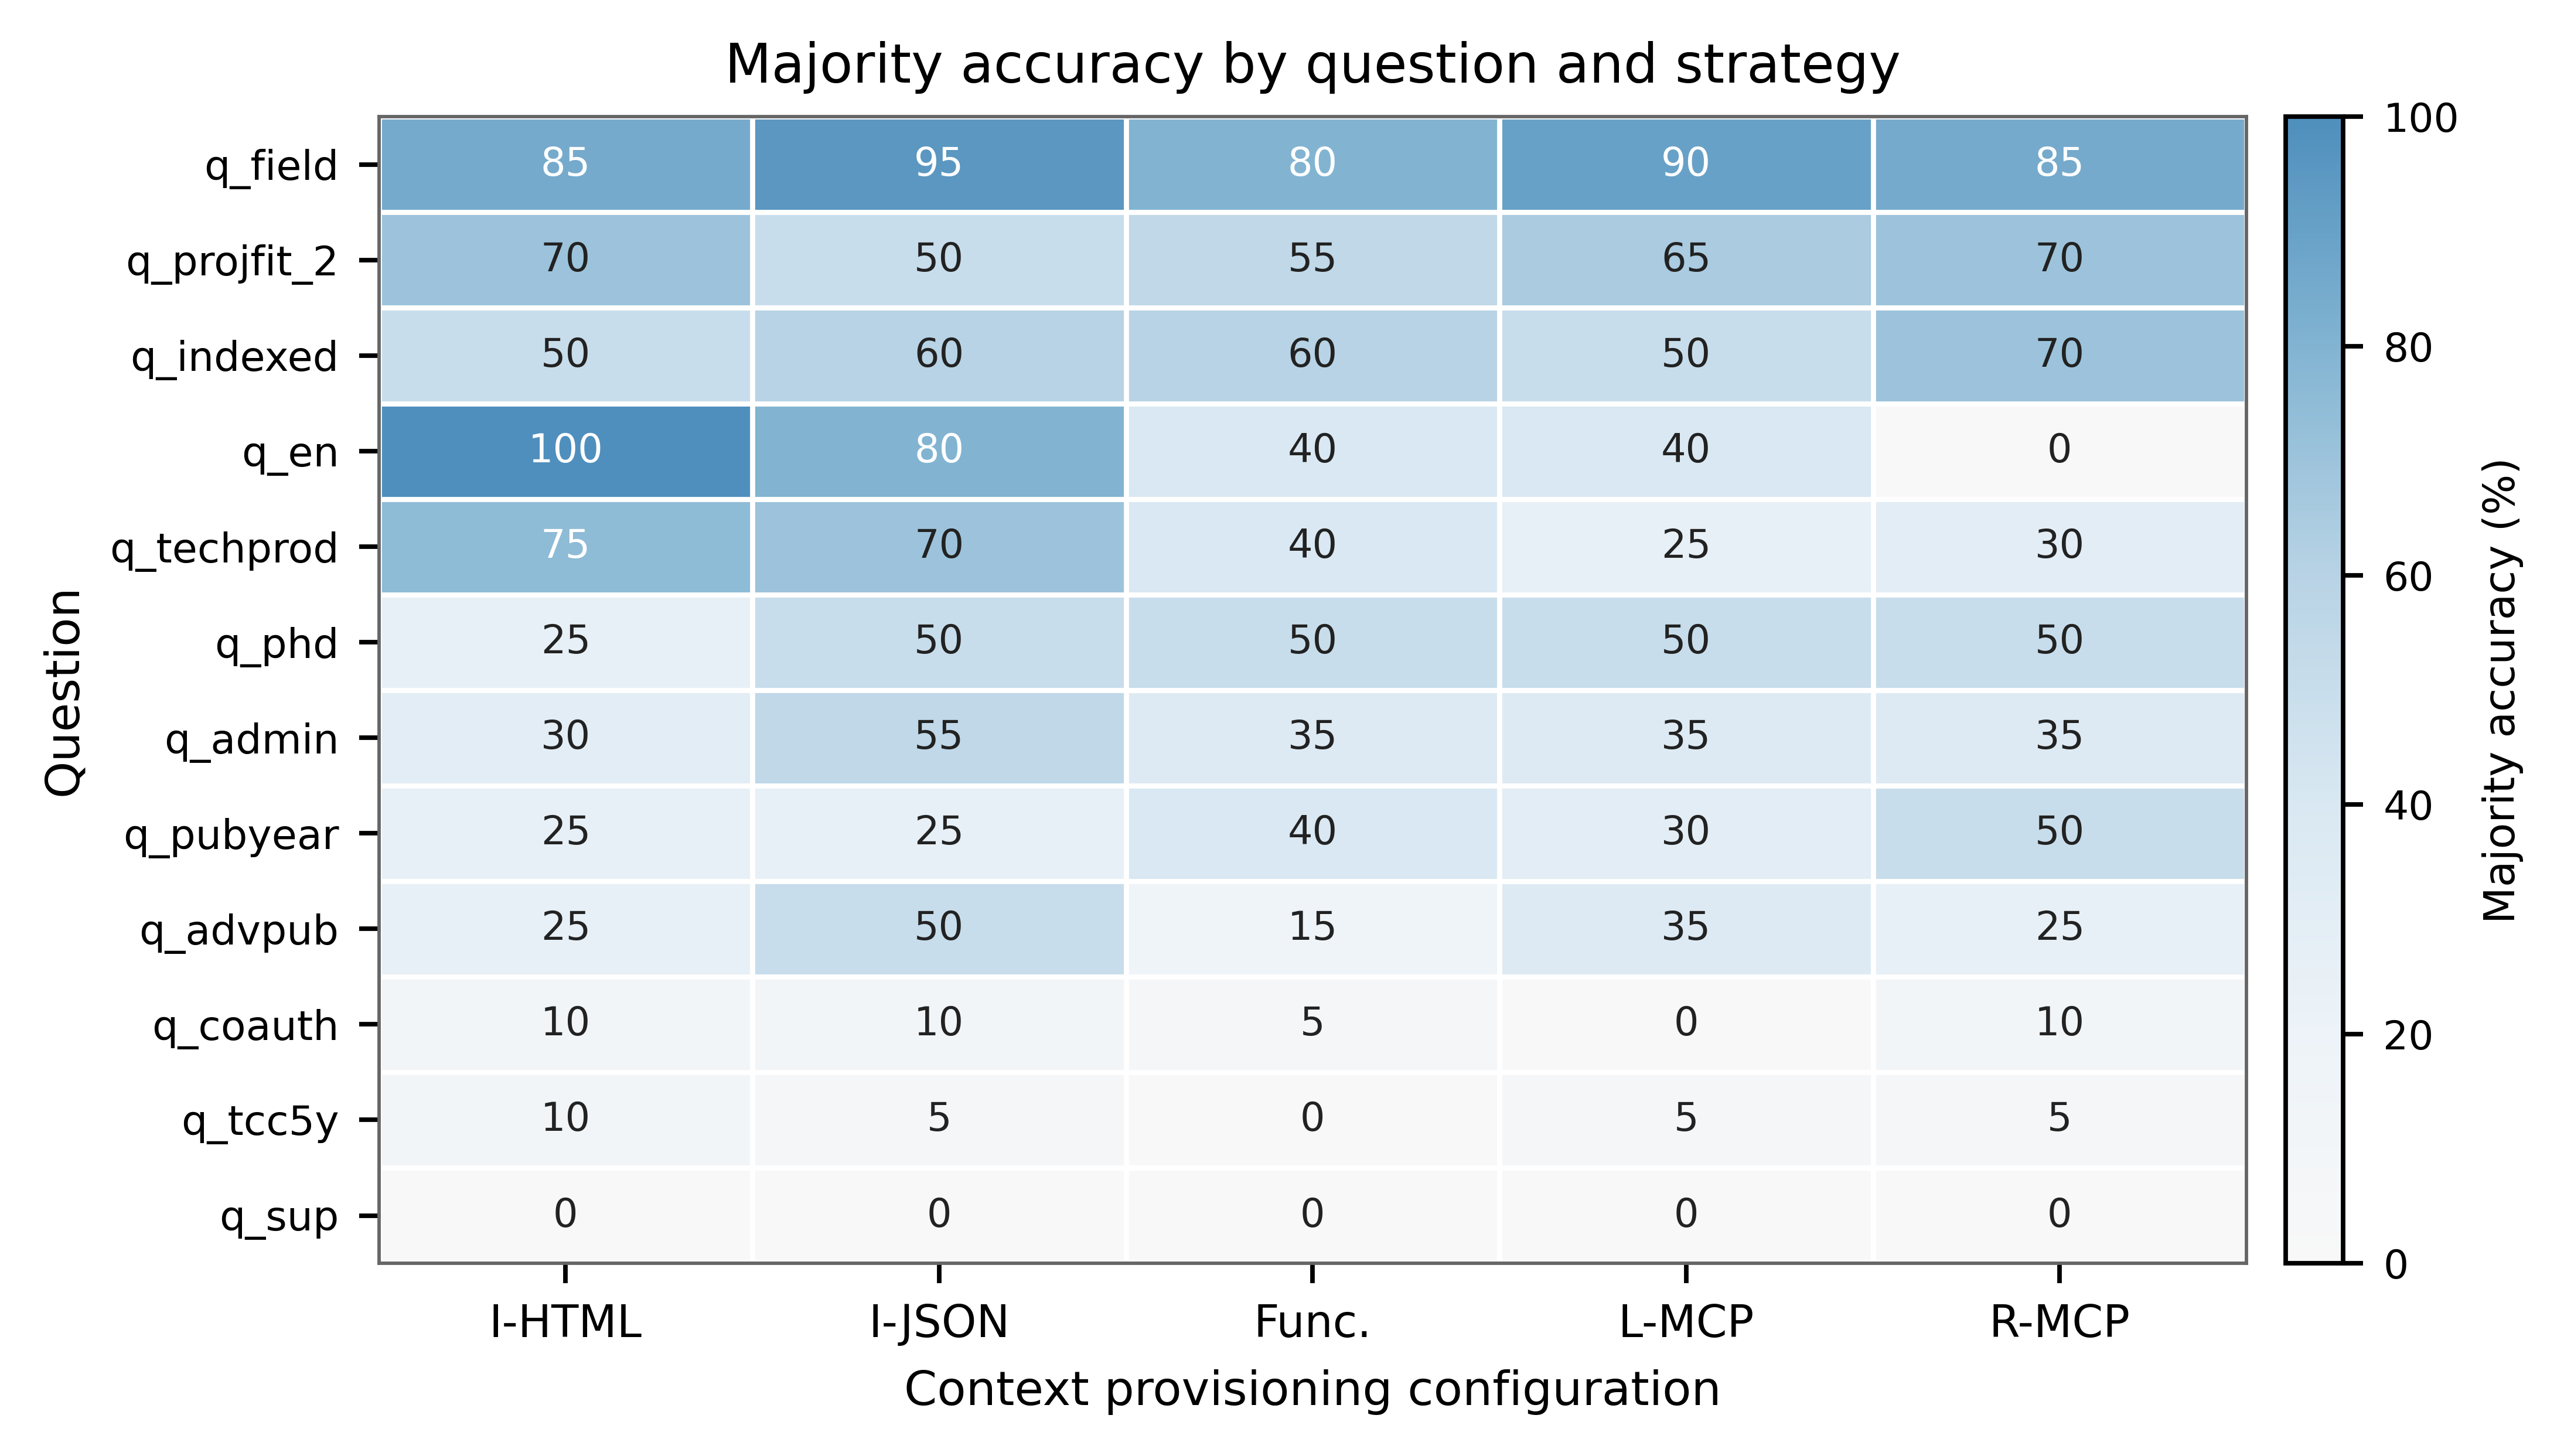

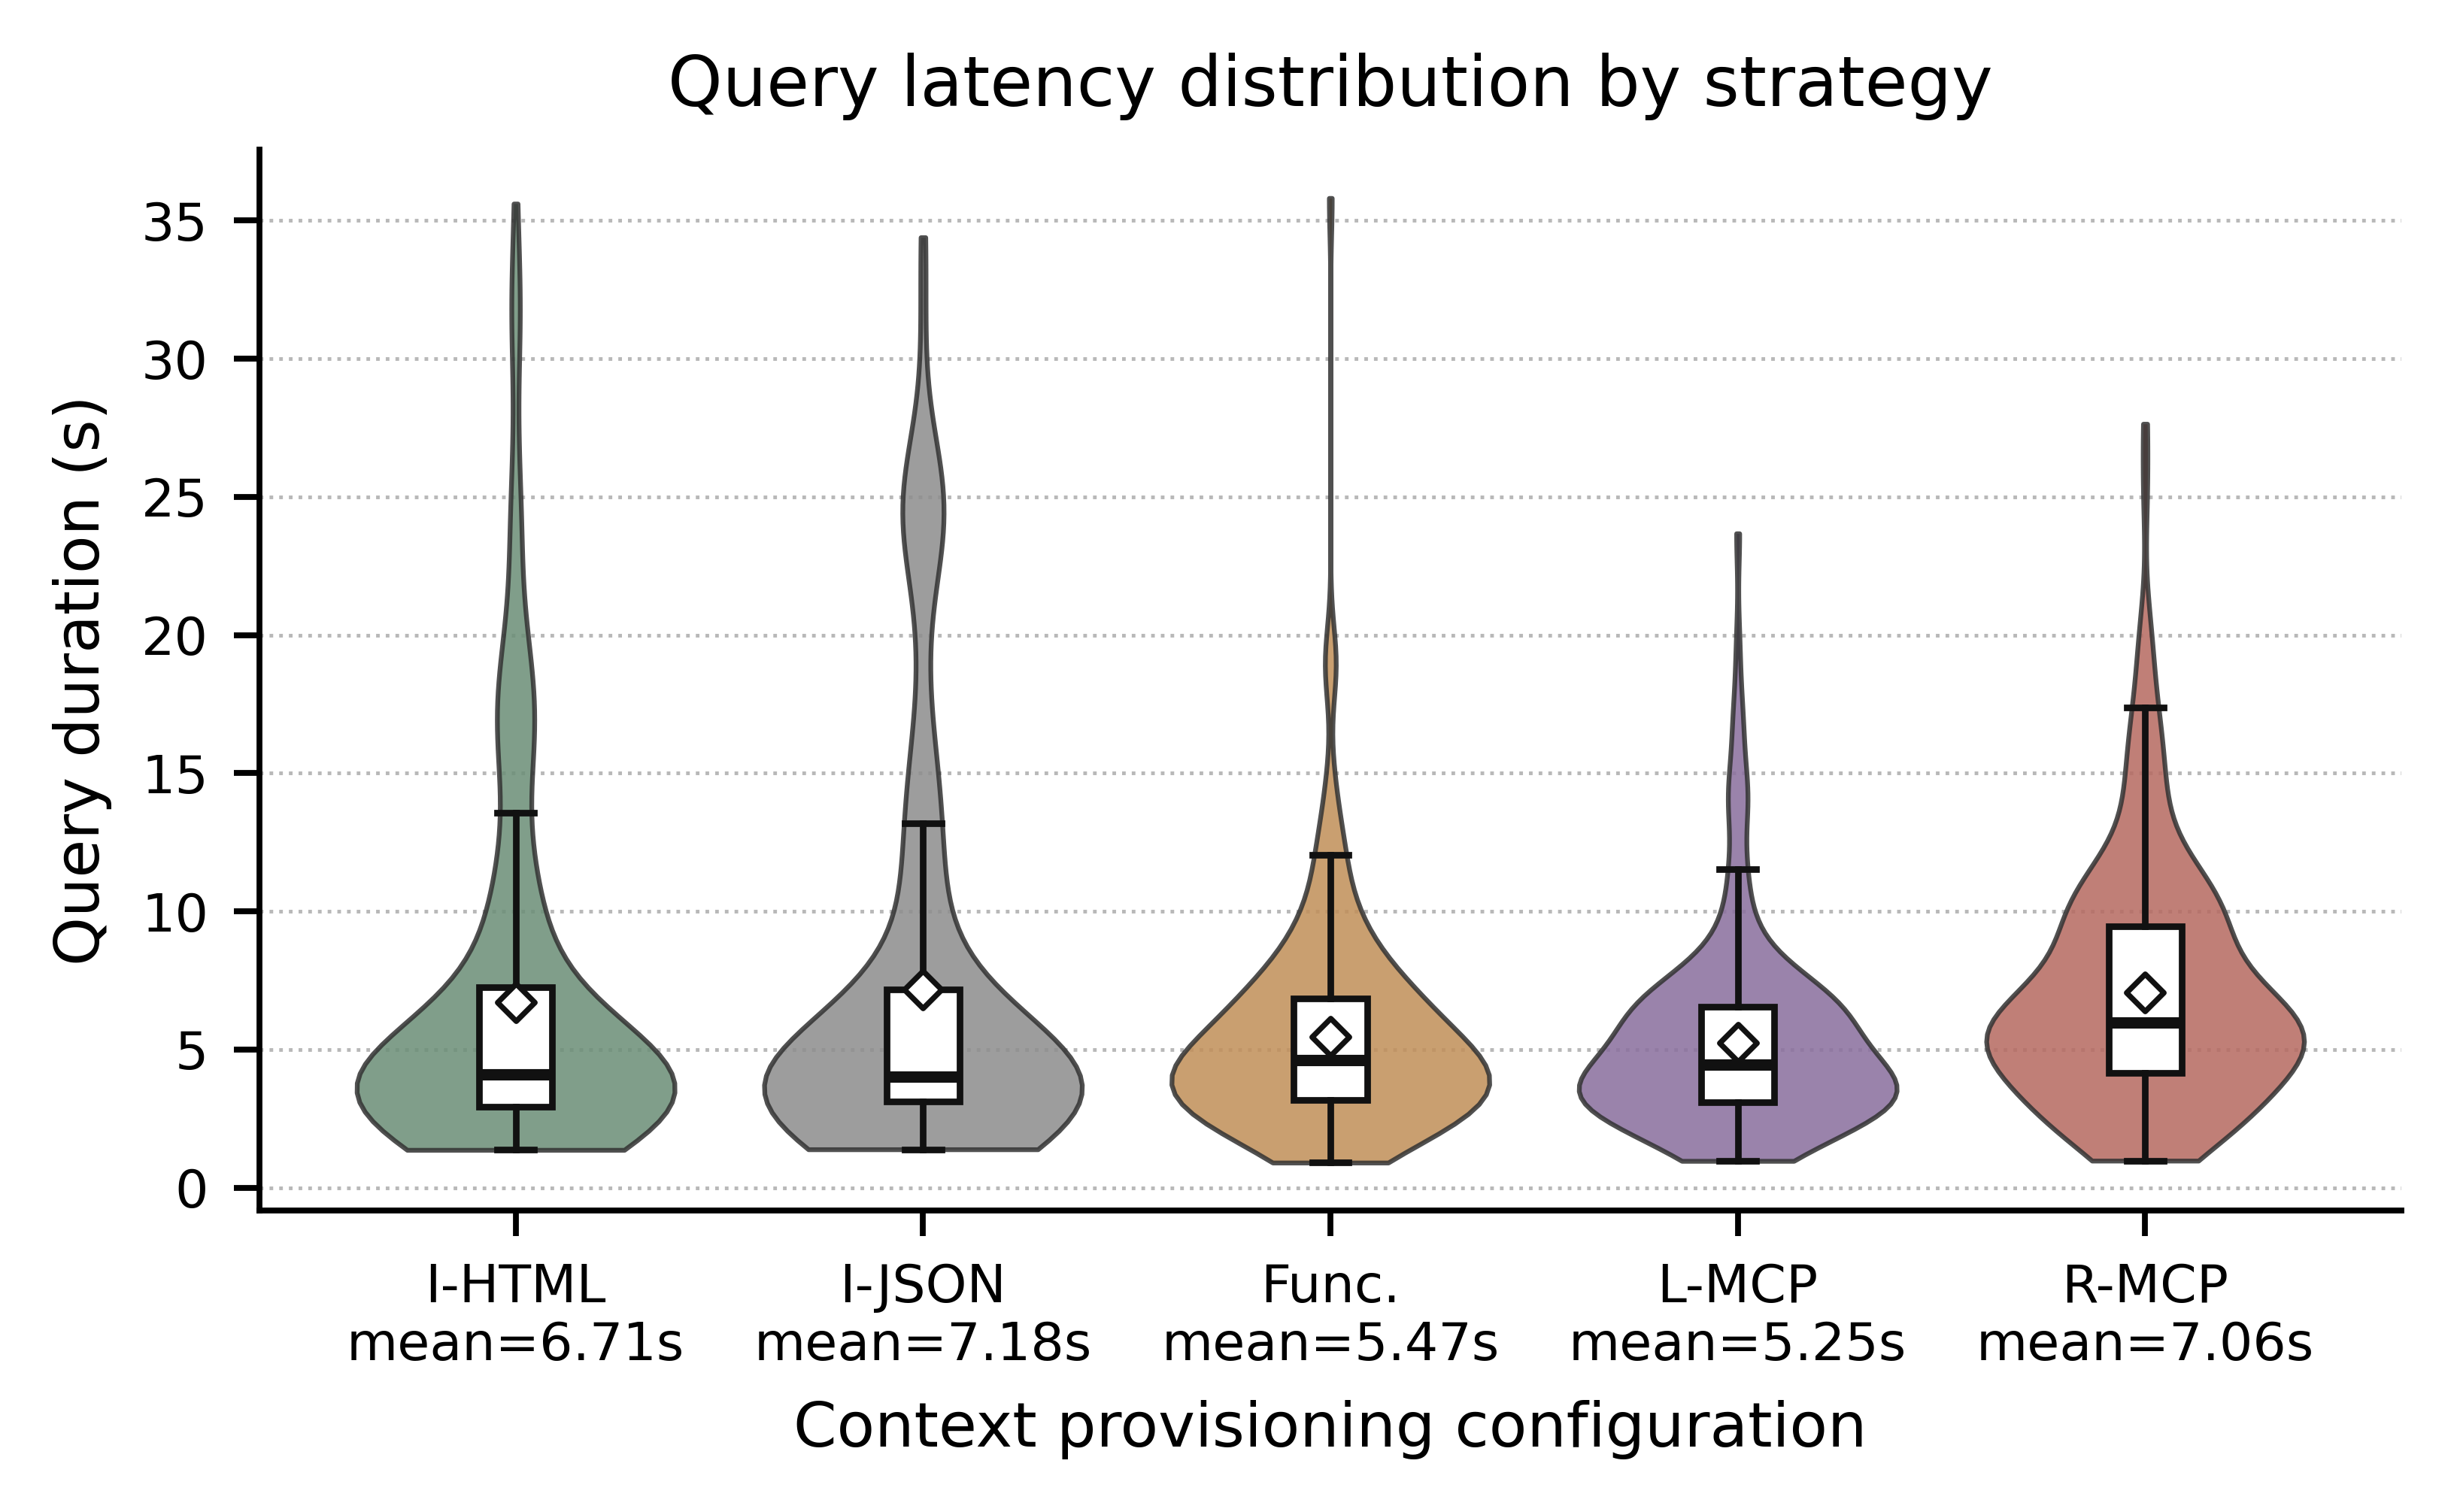

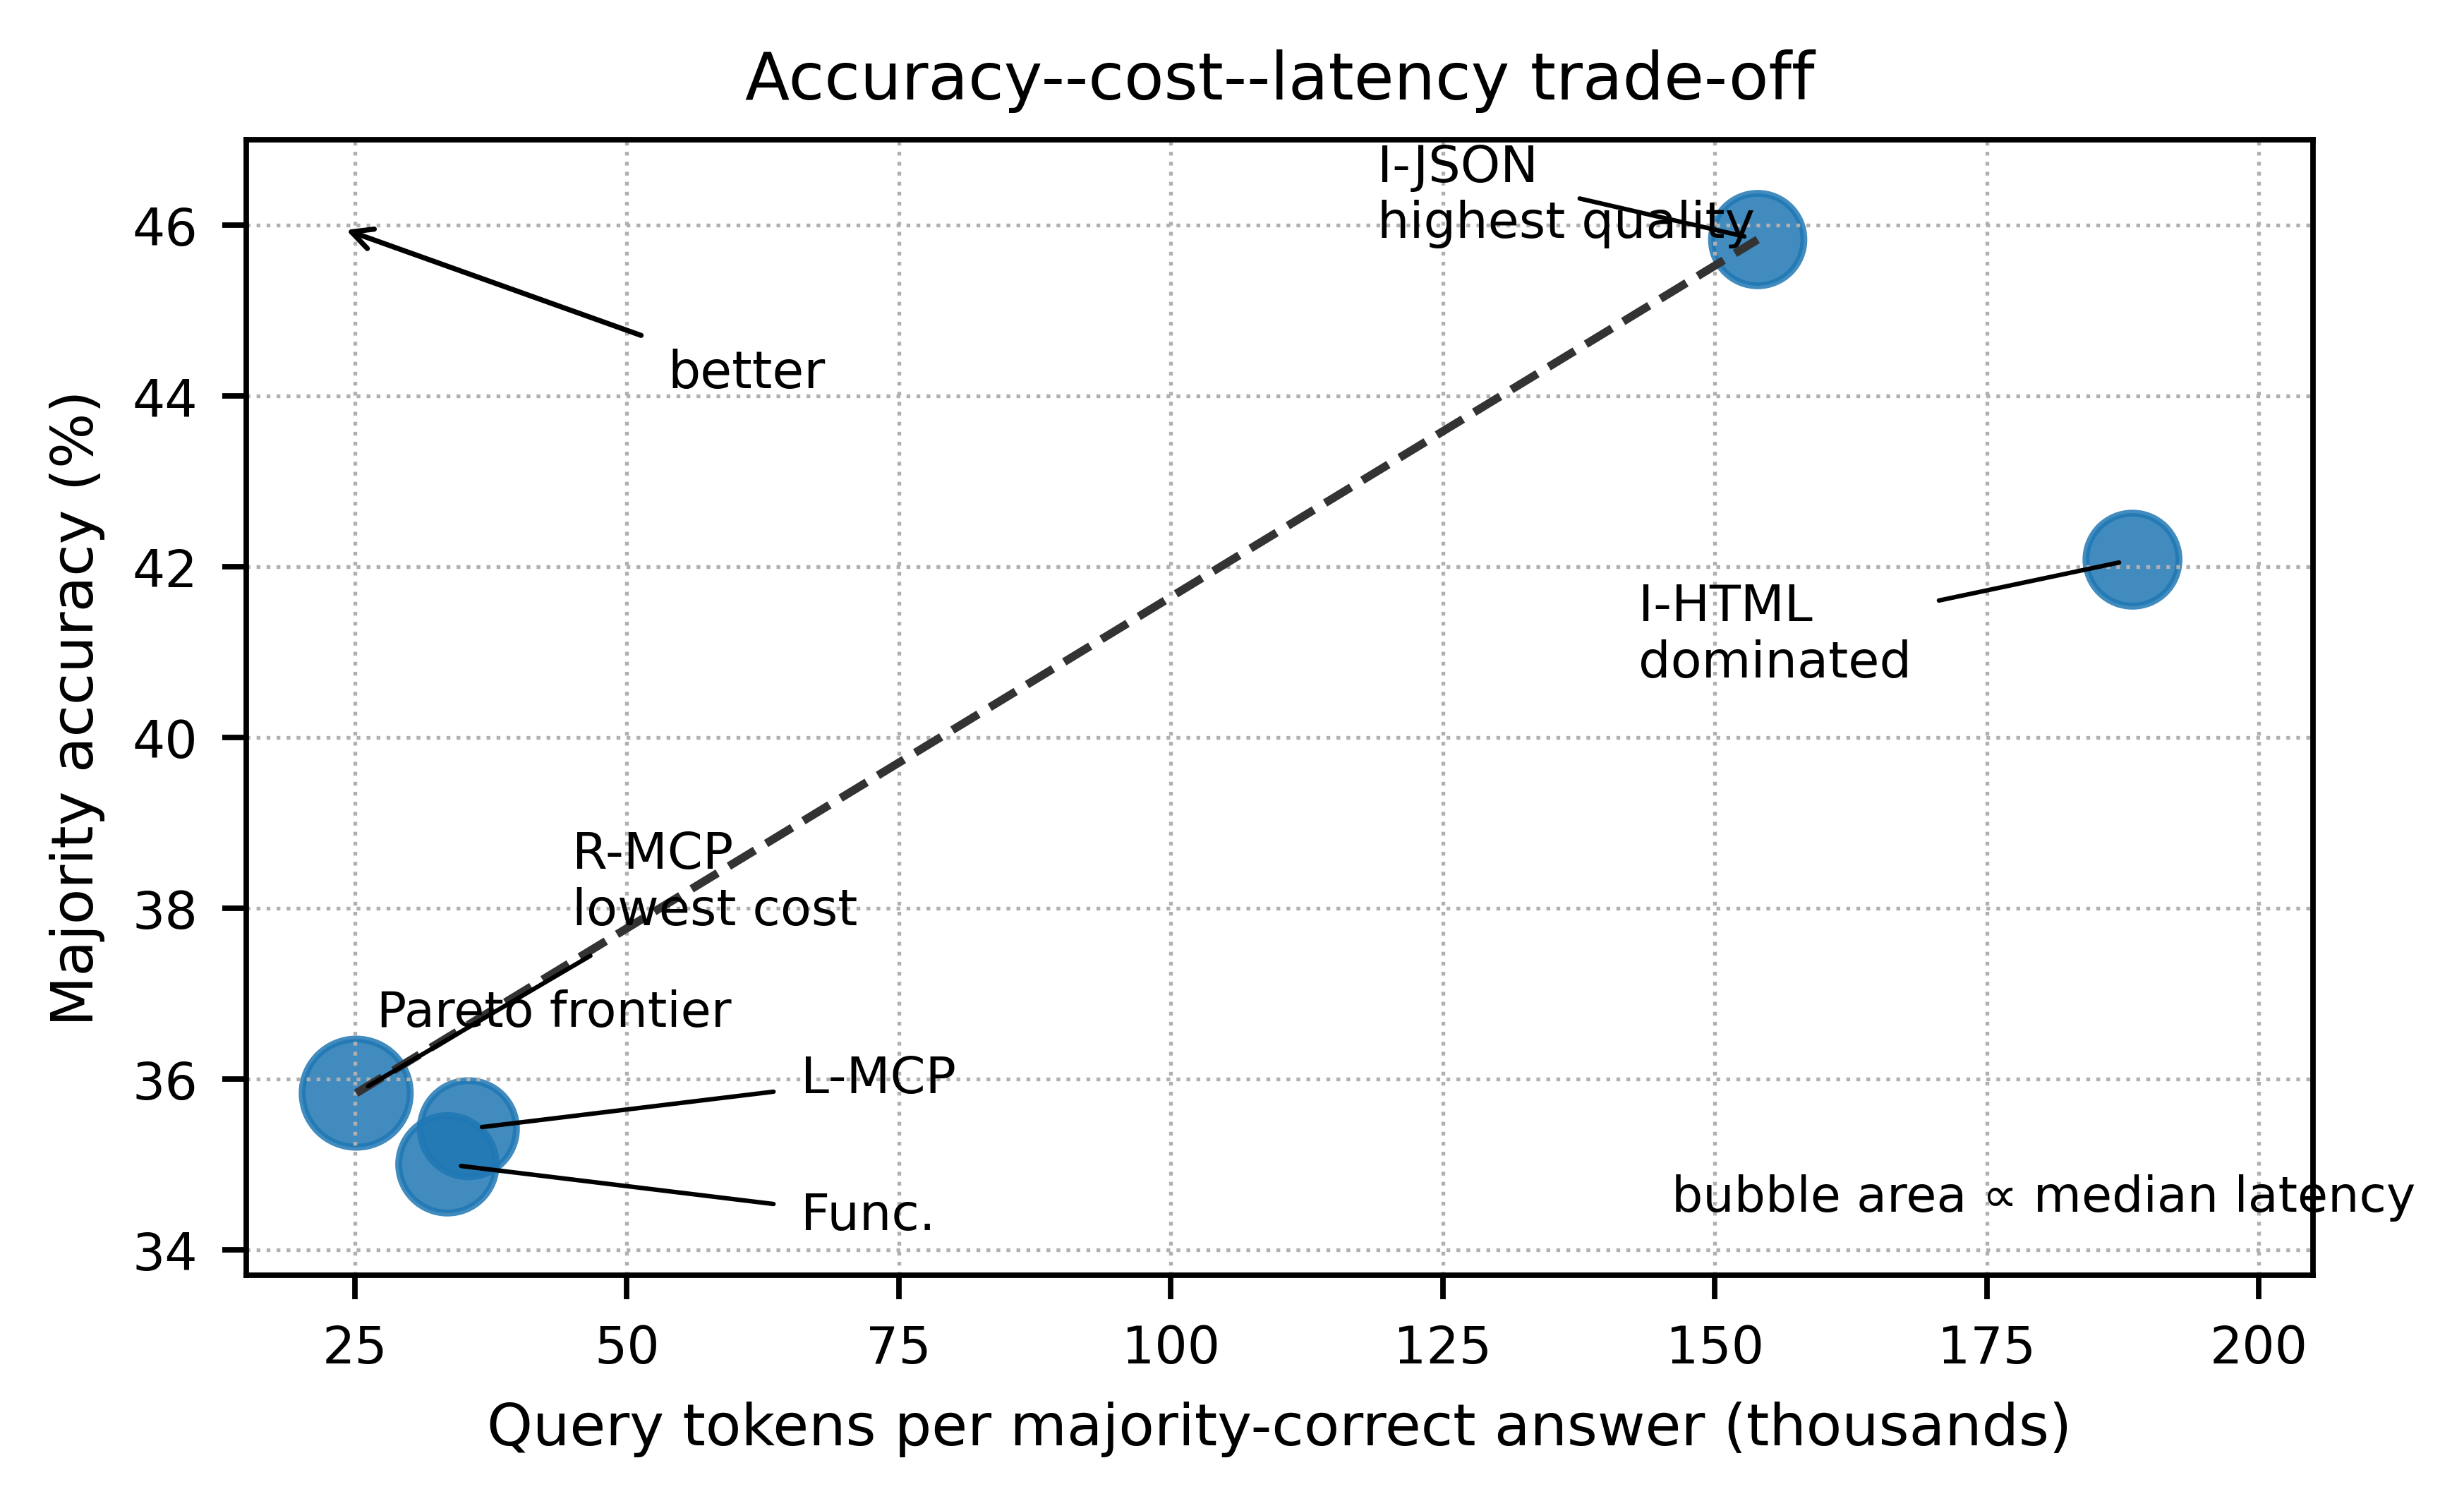

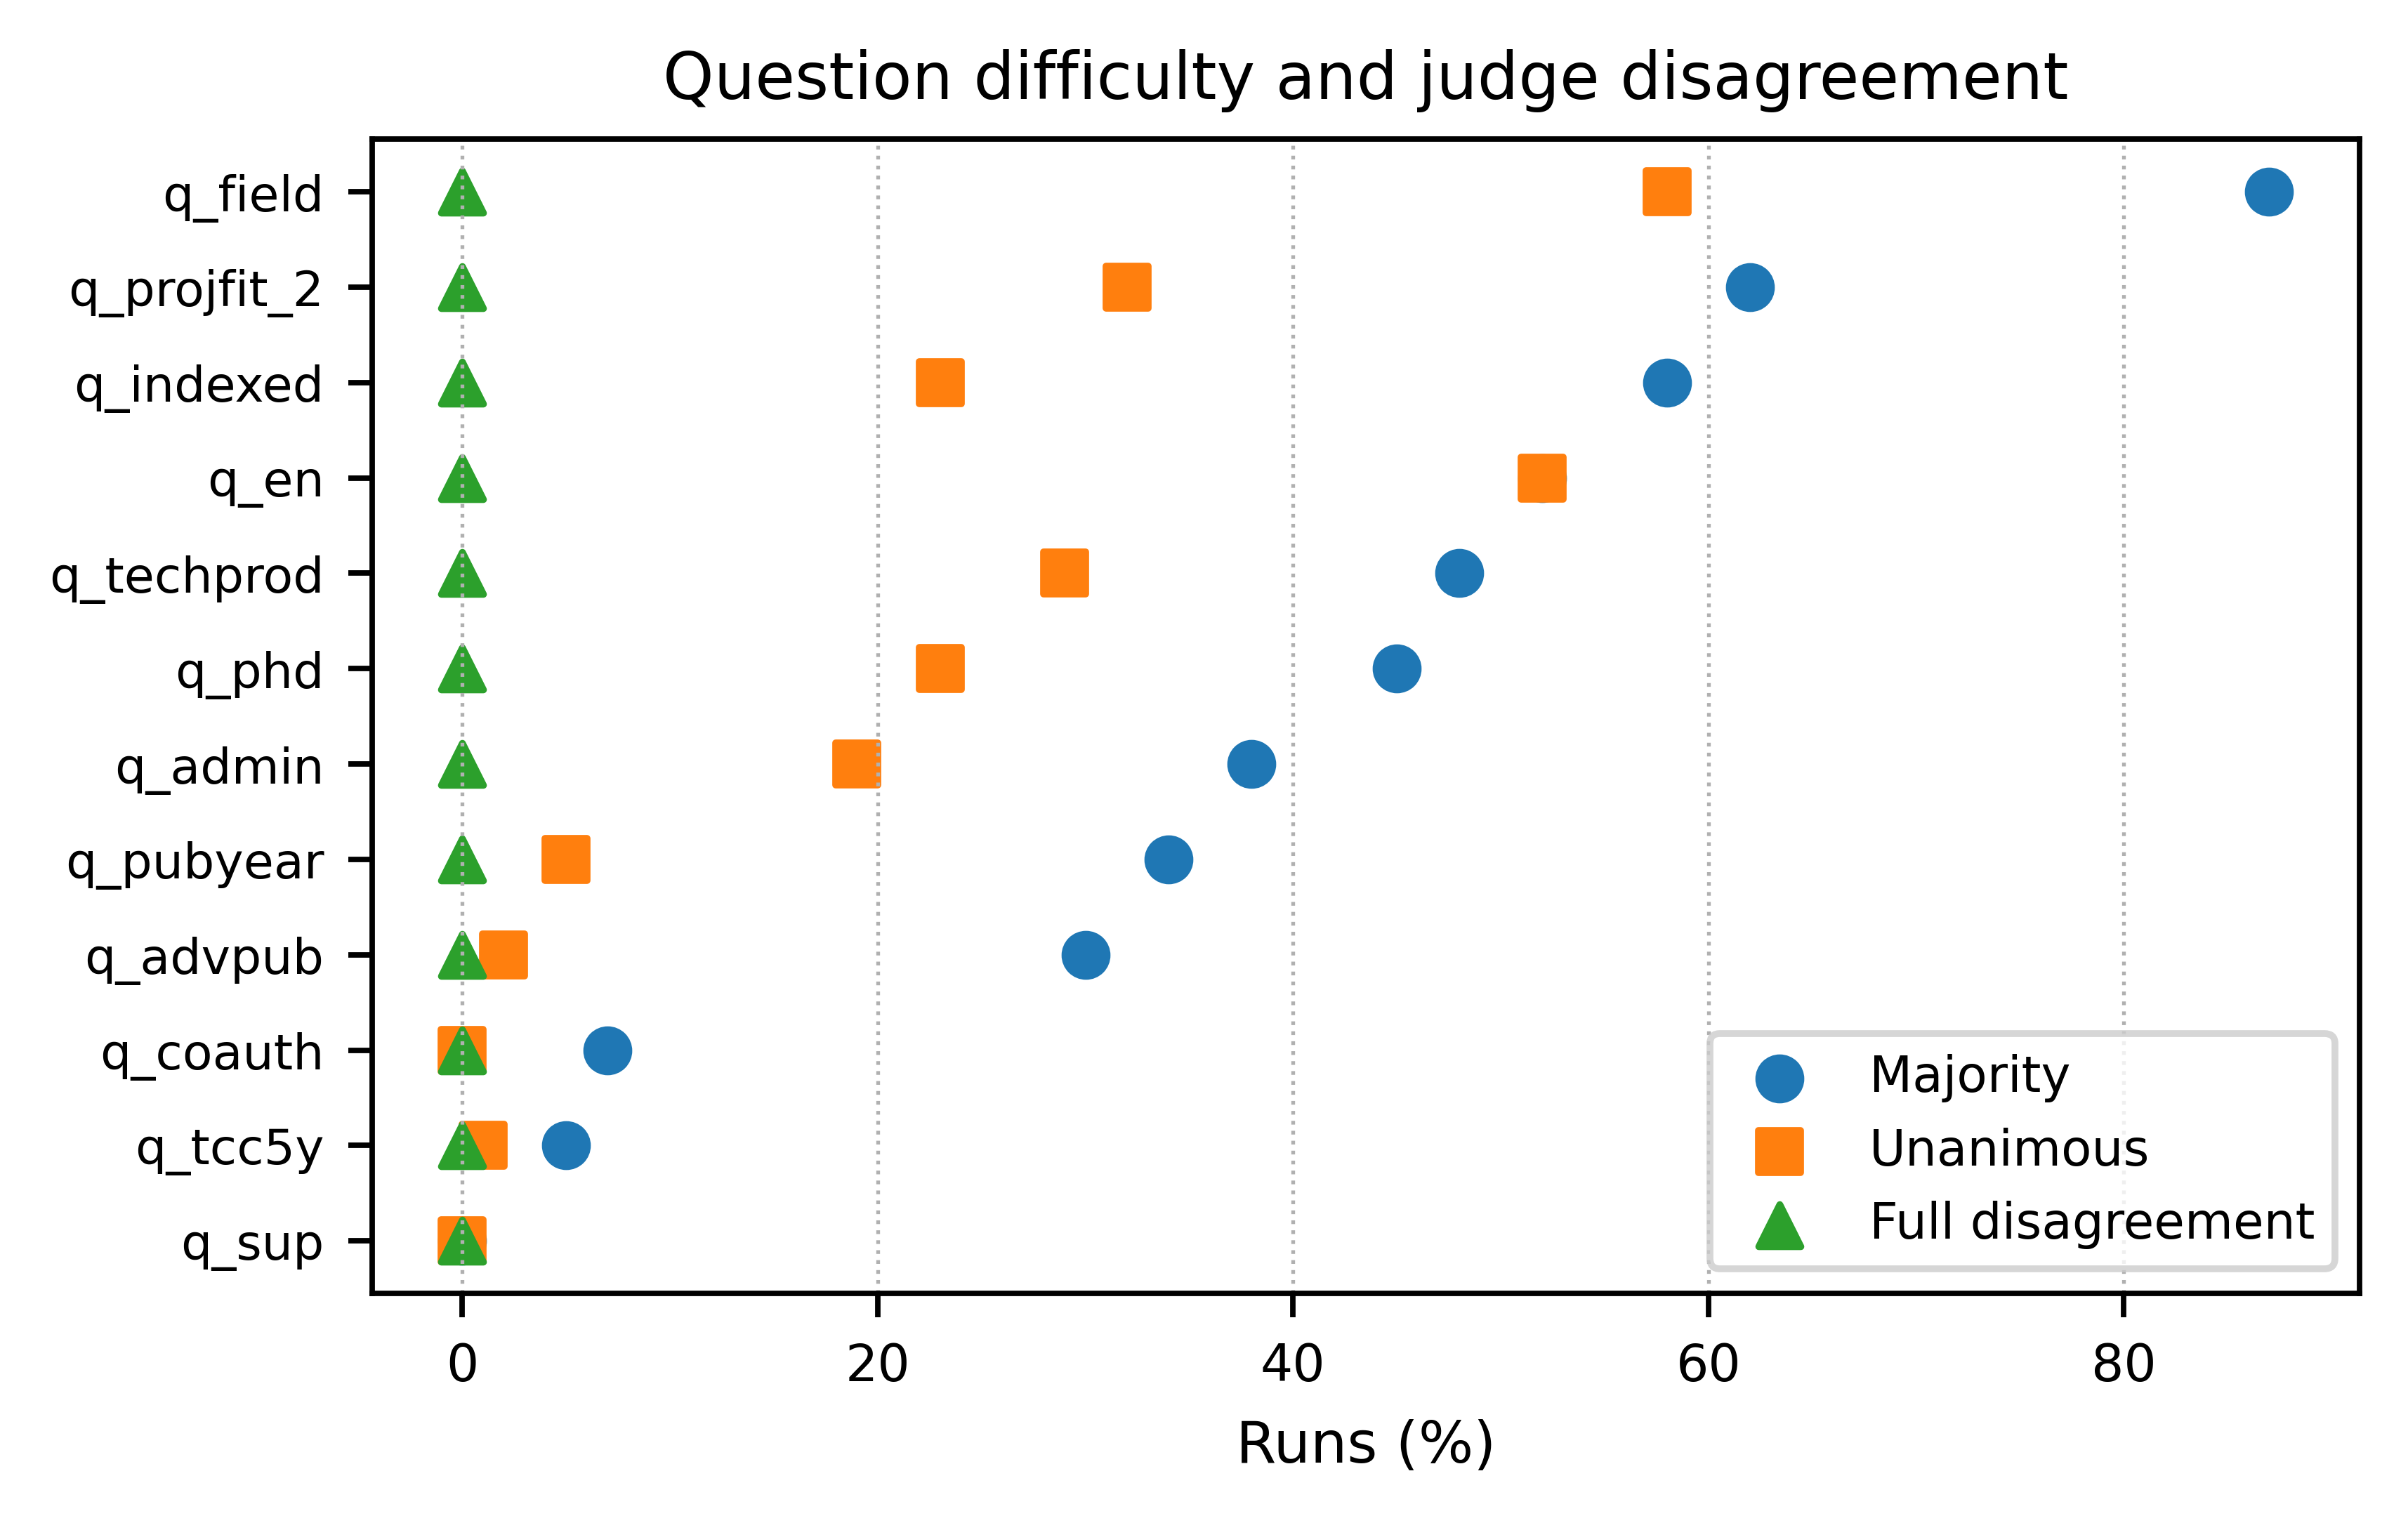

Generated files:
- tmp/article_figures_from_notebook/rq2_latency_boxplot_strategy.pdf
- tmp/article_figures_from_notebook/rq2_latency_boxplot_strategy.png
- tmp/article_figures_from_notebook/rq2_latency_violin_box_strategy_no_overlap.pdf
- tmp/article_figures_from_notebook/rq2_latency_violin_box_strategy_no_overlap.png
- tmp/article_figures_from_notebook/rq2_pareto_latency_improved.pdf
- tmp/article_figures_from_notebook/rq2_pareto_latency_improved.png
- tmp/article_figures_from_notebook/rq3_question_difficulty_disagreement.pdf
- tmp/article_figures_from_notebook/rq3_question_difficulty_disagreement.png
- tmp/article_figures_from_notebook/rq3_question_strategy_heatmap_muted.pdf
- tmp/article_figures_from_notebook/rq3_question_strategy_heatmap_muted.png


In [19]:
# ---------------------------
# 1) Heatmap: question × strategy
# ---------------------------
matrix = (
    runs.pivot_table(
        index="questionId",
        columns="Cfg.",
        values="majority_correct",
        aggfunc="mean",
    ) * 100
).reindex(QUESTION_ORDER)[CFG_ORDER]

muted_blue = LinearSegmentedColormap.from_list(
    "muted_blue",
    ["#f8f8f8", "#edf3f8", "#d9e8f2", "#b8d3e5", "#82b4d2", "#4f8fbd"],
    N=256,
)

fig, ax = plt.subplots(figsize=(6.35, 3.65), dpi=700)
im = ax.imshow(matrix.values, aspect="auto", vmin=0, vmax=100, interpolation="nearest", cmap=muted_blue)
ax.set_xticks(np.arange(len(CFG_ORDER)))
ax.set_xticklabels(CFG_ORDER, fontsize=7.8)
ax.set_yticks(np.arange(len(QUESTION_ORDER)))
ax.set_yticklabels(QUESTION_ORDER, fontsize=7.2)
ax.set_title("Majority accuracy by question and strategy", fontsize=9.5)
ax.set_xlabel("Context provisioning configuration", fontsize=8.3)
ax.set_ylabel("Question", fontsize=8.3)
ax.set_xticks(np.arange(-0.5, len(CFG_ORDER), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(QUESTION_ORDER), 1), minor=True)
ax.grid(which="minor", color="#ffffff", linewidth=0.9)
ax.tick_params(which="minor", bottom=False, left=False)
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        value = matrix.iloc[i, j]
        text_color = "#222222" if value < 72 else "#ffffff"
        ax.text(j, i, f"{value:.0f}", ha="center", va="center", fontsize=6.9, color=text_color)
for spine in ax.spines.values():
    spine.set_linewidth(0.6)
    spine.set_color("#666666")
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Majority accuracy (%)", fontsize=7.5)
cbar.ax.tick_params(labelsize=7.0)
fig.tight_layout()
heatmap_pdf = ARTICLE_FIGURES_DIR / "rq3_question_strategy_heatmap_muted.pdf"
heatmap_png = ARTICLE_FIGURES_DIR / "rq3_question_strategy_heatmap_muted.png"
fig.savefig(heatmap_pdf, bbox_inches="tight")
fig.savefig(heatmap_png, bbox_inches="tight", dpi=700)
plt.show()
plt.close(fig)

# ---------------------------
# 2) Latency violin + boxplot by strategy
# ---------------------------
fig, ax = plt.subplots(figsize=(5.25, 3.15), dpi=700)

data = [
    runs.loc[runs["Cfg."] == cfg, "durationS"].dropna().to_numpy()
    for cfg in CFG_ORDER
]
positions = np.arange(1, len(CFG_ORDER) + 1)

# Muted, paper-friendly colors.
violin_colors = ["#6B8E77", "#8D8D8D", "#C18F59", "#8A6F9E", "#B66A61"]

violins = ax.violinplot(
    data,
    positions=positions,
    widths=0.78,
    showmeans=False,
    showmedians=False,
    showextrema=False,
)

for body, color in zip(violins["bodies"], violin_colors):
    body.set_facecolor(color)
    body.set_edgecolor("#333333")
    body.set_linewidth(0.65)
    body.set_alpha(0.86)
    body.set_zorder(1)

# Boxplot layer: white box over the violin.
box_width = 0.18
ax.boxplot(
    data,
    positions=positions,
    widths=box_width,
    showmeans=False,
    showfliers=False,
    manage_ticks=False,
    patch_artist=True,
    medianprops={
        "color": "#111111",
        "linewidth": 1.45,
        "zorder": 5,
    },
    boxprops={
        "facecolor": "#FFFFFF",
        "edgecolor": "#111111",
        "linewidth": 0.9,
        "zorder": 3,
    },
    whiskerprops={
        "color": "#111111",
        "linewidth": 0.9,
        "zorder": 3,
    },
    capprops={
        "color": "#111111",
        "linewidth": 0.9,
        "zorder": 3,
    },
)

# Explicit median line inside each box, drawn over all elements.
medians = [np.median(values) for values in data]
for pos, median in zip(positions, medians):
    ax.hlines(
        y=median,
        xmin=pos - box_width / 2,
        xmax=pos + box_width / 2,
        colors="#111111",
        linewidth=1.55,
        zorder=6,
    )

# Mean marker only; text goes to x-axis labels to avoid overlapping the violins.
means = [np.mean(values) for values in data]
ax.scatter(
    positions,
    means,
    marker="D",
    s=13,
    facecolor="#FFFFFF",
    edgecolor="#111111",
    linewidth=0.75,
    zorder=6,
)

# Put mean values in the category labels, outside the plotting area.
xtick_labels = [
    f"{cfg}\nmean={mean:.2f}s"
    for cfg, mean in zip(CFG_ORDER, means)
]

ax.set_xticks(positions)
ax.set_xticklabels(xtick_labels)

ax.set_title("Query latency distribution by strategy", fontsize=9.5)
ax.set_xlabel("Context provisioning configuration", fontsize=8.5)
ax.set_ylabel("Query duration (s)", fontsize=8.5)
ax.tick_params(axis="both", labelsize=7.2)

# Sober academic grid and axes.
ax.grid(True, axis="y", linestyle=":", linewidth=0.5, color="#B8B8B8")
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Extra space for two-line tick labels.
fig.subplots_adjust(bottom=0.24)

latency_pdf = ARTICLE_FIGURES_DIR / "rq2_latency_violin_box_strategy_no_overlap.pdf"
latency_png = ARTICLE_FIGURES_DIR / "rq2_latency_violin_box_strategy_no_overlap.png"
fig.savefig(latency_pdf, bbox_inches="tight")
fig.savefig(latency_png, bbox_inches="tight", dpi=700)
plt.show()
plt.close(fig)

# ---------------------------
# 3) Pareto / trade-off view
# ---------------------------
summary = (
    runs.groupby("Cfg.", as_index=False)
    .agg(
        Majority=("majority_correct", "mean"),
        TotalTokens=("queryTokens", "sum"),
        MajorityCount=("majority_correct", "sum"),
        MedianSec=("durationS", "median"),
    )
)
summary["MajorityPct"] = summary["Majority"] * 100
summary["TokPerMajK"] = summary["TotalTokens"] / summary["MajorityCount"] / 1000.0
summary["LatencyBubble"] = 45 + summary["MedianSec"] * 34

frontier_rows = []
for _, row in summary.iterrows():
    dominated = False
    for _, other in summary.iterrows():
        if (
            other["TokPerMajK"] <= row["TokPerMajK"]
            and other["MajorityPct"] >= row["MajorityPct"]
            and (
                other["TokPerMajK"] < row["TokPerMajK"]
                or other["MajorityPct"] > row["MajorityPct"]
            )
        ):
            dominated = True
            break
    if not dominated:
        frontier_rows.append(row)
frontier = pd.DataFrame(frontier_rows).sort_values("TokPerMajK")

fig, ax = plt.subplots(figsize=(5.15, 3.15), dpi=700)
ax.scatter(summary["TokPerMajK"], summary["MajorityPct"], s=summary["LatencyBubble"], alpha=0.85)
ax.plot(frontier["TokPerMajK"], frontier["MajorityPct"], linestyle="--", linewidth=1.2, color="#333333")
annotations = {
    "R-MCP": {"xytext": (45, 38.3), "text": "R-MCP\nlowest cost"},
    "Func.": {"xytext": (66, 34.4), "text": "Func."},
    "L-MCP": {"xytext": (66, 36.0), "text": "L-MCP"},
    "I-JSON": {"xytext": (119, 46.35), "text": "I-JSON\nhighest quality"},
    "I-HTML": {"xytext": (143, 41.2), "text": "I-HTML\ndominated"},
}
for _, row in summary.iterrows():
    cfg = row["Cfg."]
    item = annotations.get(cfg, {"xytext": (row["TokPerMajK"], row["MajorityPct"]), "text": cfg})
    ax.annotate(
        item["text"],
        xy=(row["TokPerMajK"], row["MajorityPct"]),
        xytext=item["xytext"],
        fontsize=7.4,
        arrowprops={"arrowstyle": "-", "linewidth": 0.65},
        ha="left",
        va="center",
    )
ax.annotate("better", xy=(23, 46.0), xytext=(61, 44.1), fontsize=7.5,
            arrowprops={"arrowstyle": "->", "linewidth": 0.75}, ha="center")
ax.text(146, 34.45, "bubble area ∝ median latency", fontsize=7.2)
ax.text(27, 36.62, "Pareto frontier", fontsize=7.2)
ax.set_xlabel("Query tokens per majority-correct answer (thousands)", fontsize=8.5)
ax.set_ylabel("Majority accuracy (%)", fontsize=8.5)
ax.set_title("Accuracy--cost--latency trade-off", fontsize=9.5)
ax.set_xlim(15, 205)
ax.set_ylim(33.7, 47.0)
ax.tick_params(axis="both", labelsize=7.5)
ax.grid(True, linestyle=":", linewidth=0.55)
fig.tight_layout()
pareto_pdf = ARTICLE_FIGURES_DIR / "rq2_pareto_latency_improved.pdf"
pareto_png = ARTICLE_FIGURES_DIR / "rq2_pareto_latency_improved.png"
fig.savefig(pareto_pdf, bbox_inches="tight")
fig.savefig(pareto_png, bbox_inches="tight", dpi=700)
plt.show()
plt.close(fig)

# ---------------------------
# 4) Question difficulty and full disagreement
# ---------------------------
q_summary = (
    runs.groupby("questionId", as_index=False)
    .agg(
        Majority=("majority_correct", "mean"),
        Unanimous=("unanimous_correct", "mean"),
        FullDis=("full_disagreement", "mean"),
    )
)
q_summary["MajorityPct"] = q_summary["Majority"] * 100
q_summary["UnanimousPct"] = q_summary["Unanimous"] * 100
q_summary["FullDisPct"] = q_summary["FullDis"] * 100
q_summary = q_summary.set_index("questionId").reindex(QUESTION_ORDER).reset_index()

fig, ax = plt.subplots(figsize=(5.0, 3.2), dpi=700)
y = np.arange(len(q_summary))
ax.scatter(q_summary["MajorityPct"], y, s=38, label="Majority")
ax.scatter(q_summary["UnanimousPct"], y, s=38, marker="s", label="Unanimous")
ax.scatter(q_summary["FullDisPct"], y, s=38, marker="^", label="Full disagreement")
ax.set_yticks(y)
ax.set_yticklabels(q_summary["questionId"], fontsize=7.2)
ax.invert_yaxis()
ax.set_xlabel("Runs (%)", fontsize=8.5)
ax.set_title("Question difficulty and judge disagreement", fontsize=9.5)
ax.tick_params(axis="x", labelsize=7.5)
ax.grid(True, axis="x", linestyle=":", linewidth=0.55)
ax.legend(fontsize=7.3, loc="lower right")
fig.tight_layout()
disagreement_pdf = ARTICLE_FIGURES_DIR / "rq3_question_difficulty_disagreement.pdf"
disagreement_png = ARTICLE_FIGURES_DIR / "rq3_question_difficulty_disagreement.png"
fig.savefig(disagreement_pdf, bbox_inches="tight")
fig.savefig(disagreement_png, bbox_inches="tight", dpi=700)
plt.show()
plt.close(fig)

print("Generated files:")
for p in sorted(ARTICLE_FIGURES_DIR.iterdir()):
    print("-", p)


### Optional: export a standalone script

This cell writes a standalone script equivalent to the notebook figure-generation process.


In [18]:
from pathlib import Path

script_path = Path("scripts/generate_figures.py")
if script_path.exists():
    print("Standalone script already available at:", script_path)
else:
    print("Standalone script not found. Use the notebook cells above instead.")


Standalone script already available at: scripts/generate_figures.py
